# Heat energy model — monthly BVAR-SV-outlier

This notebook estimates the heat energy component of the energy-inflation suite. The endogenous block contains monthly absolute changes in wholesale natural-gas prices, PPI Energy and the HICP heat energy index. The model uses 12 lags and no deterministic seasonal regressors.

## 1. Imports and configuration

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() or (candidate / "src").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd())
MODEL_DIR_CANDIDATES = [
    PROJECT_ROOT / "src" / "model",
    PROJECT_ROOT,
    Path.cwd(),
]
for candidate in MODEL_DIR_CANDIDATES:
    required_modules = (
        "energy_bvar_model.py",
        "energy_bvar_monthly_hicp.py",
        "energy_bvar_plot.py",
        "energy_bvar_io.py",
    )
    if all((candidate / name).exists() for name in required_modules):
        sys.path.insert(0, str(candidate))
        MODEL_DIR = candidate
        break
else:
    raise FileNotFoundError(
        "Place energy_bvar_model.py, energy_bvar_monthly_hicp.py, "
        "energy_bvar_plot.py and energy_bvar_io.py beside this notebook "
        "or in src/model/."
    )

from energy_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    coefficient_posterior_tables,
    forecast_bvar_sv_outlier,
    forecast_error_variance_decomposition,
    forecast_horizon_table,
    historical_decomposition,
    impulse_responses,
    make_bvar_svo_prior,
    mcmc_diagnostics,
    nowcast_summary_table,
    path_horizon_table,
    posterior_outlier_probability,
    posterior_predictive_statistics,
    prepare_bvar_panel,
    residual_diagnostic_table,
    run_energy_bvar,
    stability_diagnostics,
    stationarity_tests,
)
from energy_bvar_io import save_energy_bvar_result
from energy_bvar_monthly_hicp import (
    forecast_hicp_component,
    load_monthly_hicp_component_panel,
    monthly_hicp_component_spec,
    monthly_hicp_series_construction_table,
)
from energy_bvar_plot import (
    format_number,
    plot_absolute_differences,
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_data_levels,
    plot_fevd,
    plot_forecast_comparison,
    plot_hicp_forecast_fan,
    plot_historical_decomposition,
    plot_impulse_responses,
    plot_minnesota_prior_by_equation,
    plot_nowcast_fan,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_short_forecast_fan,
    plot_shrinkage_comparison,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    plot_volatility_decomposition,
    style_numeric_table,
)

pd.set_option("display.max_rows", 180)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 180)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
})

COMPONENT = "heat_energy"
SPEC = monthly_hicp_component_spec(COMPONENT)
SEED = 42
P = 12
VARIABLES = SPEC["variables"]
TARGET = SPEC["target"]
UNITS = SPEC["units"]
SAVE_RESULTS = False
RESULTS_ROOT = PROJECT_ROOT / "results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model modules: {MODEL_DIR}")
print(f"Component: {COMPONENT}")

Project root: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
Model modules: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model
Component: heat_energy


## 2. Data

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260805\heat_energy_monthly.csv
Sample calendar: 1996-01-01 to 2026-08-01


,series_type,model_unit,source_inputs,construction,note
natural_gas_wholesale,chain-linked wholesale price,EUR/MWh,"Bloomberg TTF; World Bank Natural gas, Europe; EUR/USD","Bloomberg TTF monthly mean; earlier months backcast with the World Bank Natural gas, Europe proxy via backward chain-linking. The proxy level is pinned to TTF at the anchor month; no overlap window and no level regression are estimated.","The paper uses Energy Intelligence European border gas. World Bank Natural gas, Europe is the public substitute and belongs to the same European border/import-price family. TTF anchor month: 2011-02-01."
ppi_energy,producer-price index,Index,Haver PPI Energy (H025PP@G10),Monthly Haver level; no source-stage transformation.,The notebook applies an absolute monthly difference before estimation.
hicp_heat_energy,consumer-price index,HICP index,Haver HICP heat energy (H023HW55@EUDATA),Monthly Haver level; no tax reconstruction is applied.,The notebook forecasts the HICP level directly and derives YoY inflation ex post.


,natural_gas_wholesale,ppi_energy,hicp_heat_energy
date,,,
2025-09-01,32.02,124.03,100.03
2025-10-01,32.04,123.81,101.02
2025-11-01,30.66,124.13,101.52
2025-12-01,27.42,123.82,101.52
2026-01-01,34.52,124.32,101.97
2026-02-01,32.51,123.74,102.14
2026-03-01,52.63,128.65,102.65
2026-04-01,45.26,131.24,102.12
2026-05-01,47.34,131.96,103.05


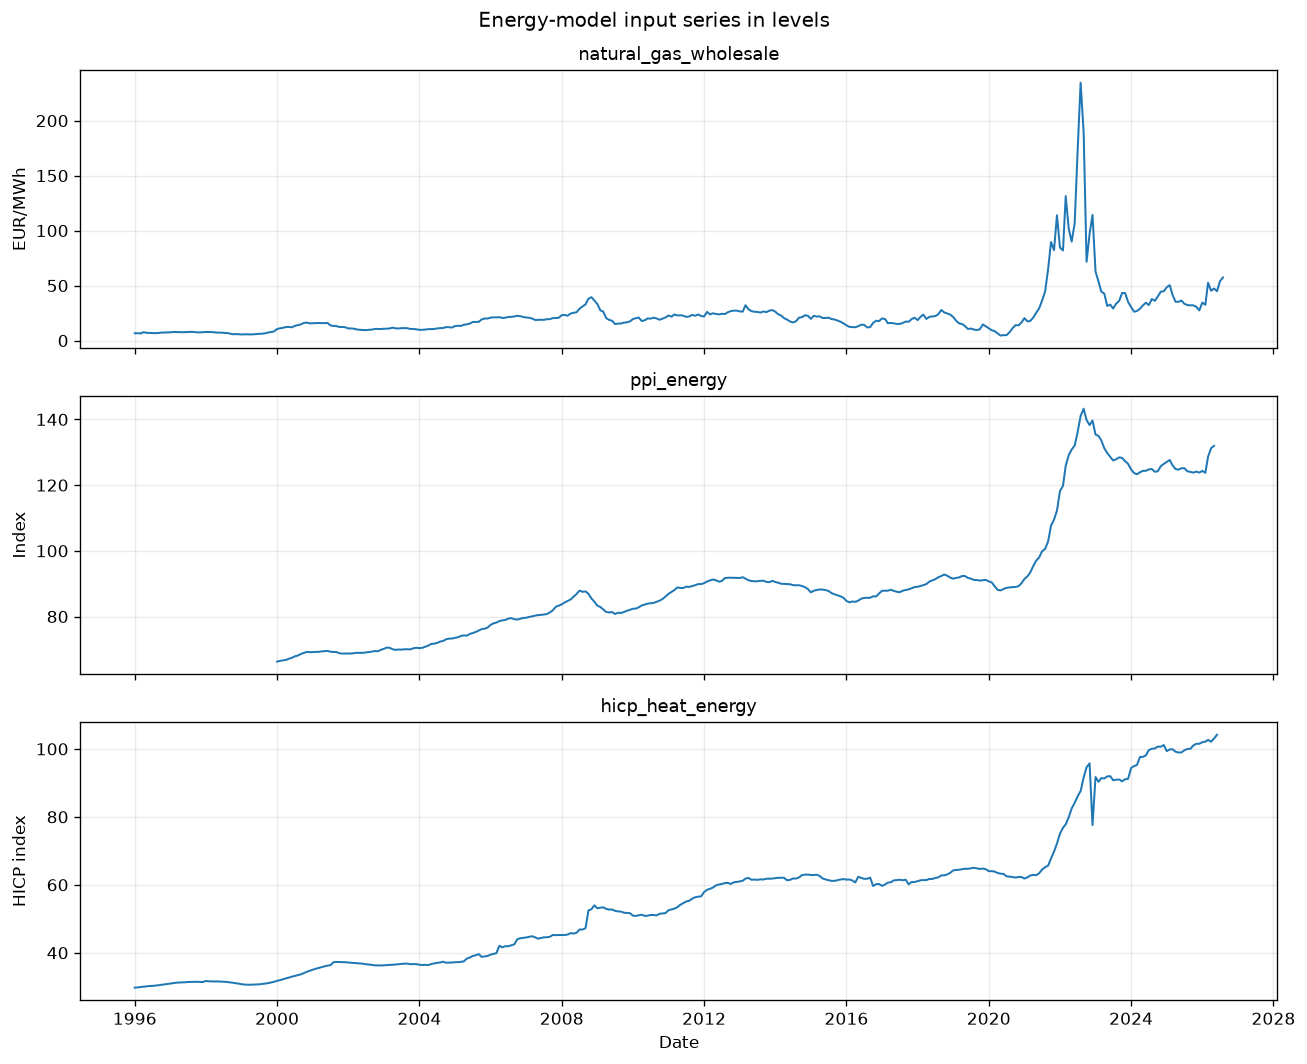

In [2]:
# Set VINTAGE = "YYYYMMDD" to force one processed vintage.
VINTAGE = None
PROCESSED_ROOT = PROJECT_ROOT / "data" / "processed"

if VINTAGE is None:
    candidates = sorted(
        path for path in PROCESSED_ROOT.glob("*/heat_energy_monthly.csv")
        if path.is_file()
    )
    if not candidates:
        raise FileNotFoundError(
            f"No heat_energy_monthly.csv found below {PROCESSED_ROOT}."
        )
    COMPONENT_DATASET = candidates[-1]
else:
    COMPONENT_DATASET = PROCESSED_ROOT / VINTAGE / "heat_energy_monthly.csv"

levels = load_monthly_hicp_component_panel(
    COMPONENT_DATASET,
    component=COMPONENT,
    variables=VARIABLES,
)

print(f"Dataset: {COMPONENT_DATASET}")
print(f"Sample calendar: {levels.index.min().date()} to {levels.index.max().date()}")

display(style_numeric_table(
    monthly_hicp_series_construction_table(COMPONENT_DATASET, COMPONENT),
    caption=f"Construction of the {SPEC['label']}-model level series",
))
display(style_numeric_table(
    levels.tail(12),
    caption="Latest processed levels",
))
plot_data_levels(levels, units=UNITS)
plt.show()

### Absolute monthly changes

The endogenous vector is ordered from upstream market prices to the consumer-price target:

$$
y_t =
\begin{bmatrix}
\Delta P_t^{\mathrm{gas}} \\
\Delta P_t^{\mathrm{PPI\ energy}} \\
\Delta HICP_t^{\mathrm{heat energy}}
\end{bmatrix},
\qquad
\Delta x_t=x_t-x_{t-1}.
$$

All three variables remain in absolute differences rather than log differences.

,value
balanced_change_start,2000-02-01 00:00:00
balanced_change_end,2026-05-01 00:00:00
balanced_changes,316
VAR_regression_observations,304
regression_columns_per_equation,37
ragged_edge_months,3
latest_calendar_month,2026-08-01 00:00:00


,natural_gas_wholesale,ppi_energy,hicp_heat_energy
date,,,
2026-06-01,-2.48,—,1.12
2026-07-01,9.11,—,—
2026-08-01,3.43,—,—


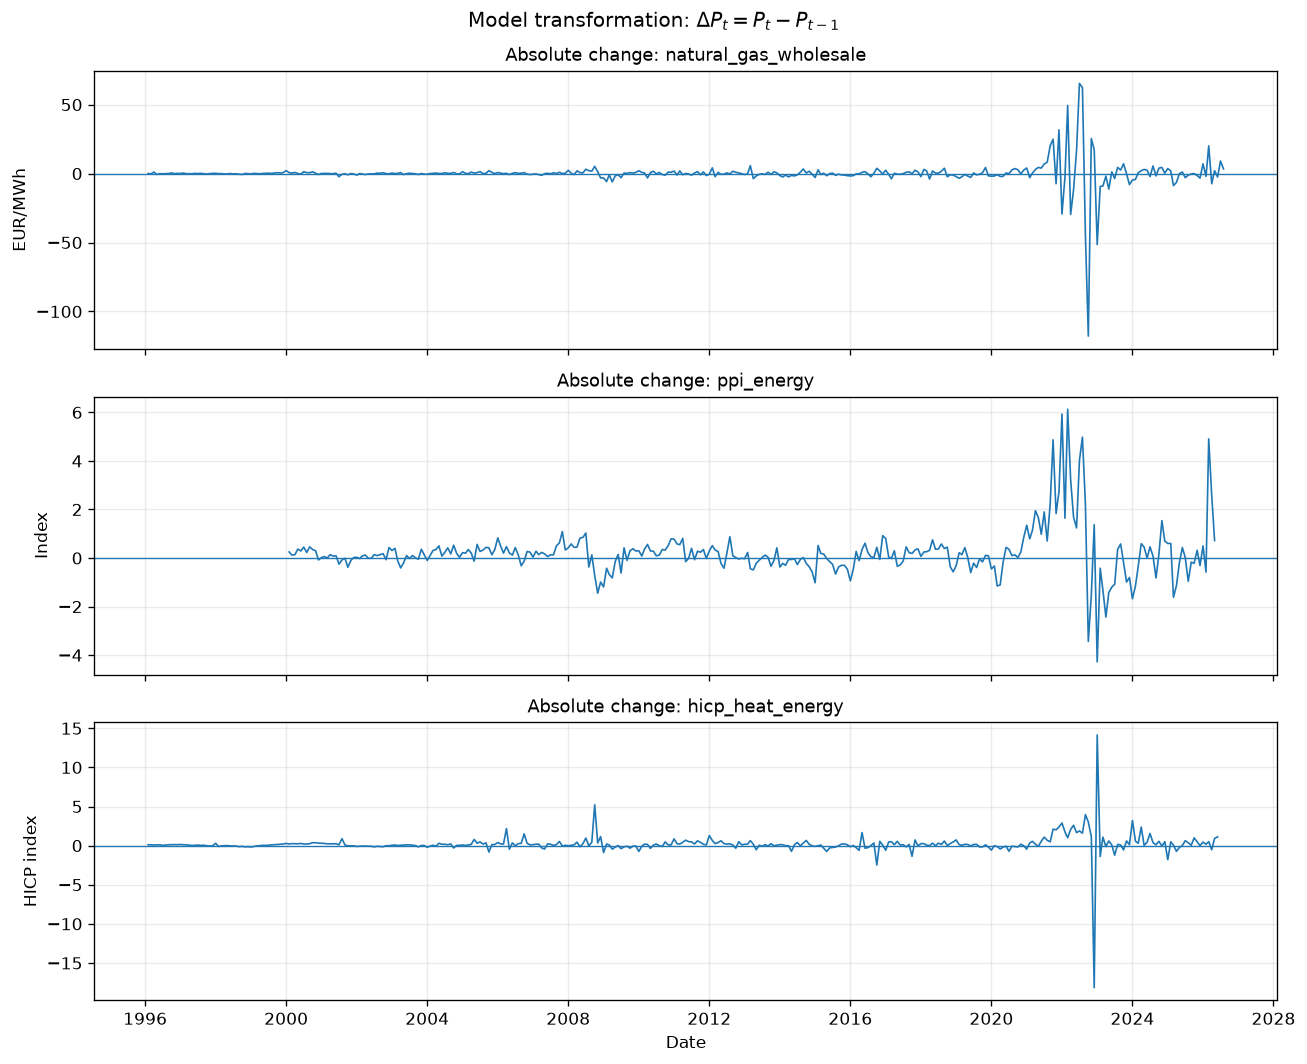

In [3]:
prep = prepare_bvar_panel(
    levels,
    p=P,
    variables=VARIABLES,
)

transformation_summary = pd.Series({
    "balanced_change_start": prep["balanced_start"],
    "balanced_change_end": prep["balanced_end"],
    "balanced_changes": prep["n_balanced_changes"],
    "VAR_regression_observations": prep["n_regression_observations"],
    "regression_columns_per_equation": prep["k"],
    "ragged_edge_months": prep["n_ragged_months"],
    "latest_calendar_month": prep["last_calendar_date"],
})
display(style_numeric_table(
    transformation_summary.to_frame("value"),
    caption="Transformation and estimation sample",
))
display(style_numeric_table(
    prep["ragged"],
    caption="Ragged-edge absolute changes",
))
plot_absolute_differences(prep["differences"], units=UNITS)
plt.show()

## 3. Model

For $t=1,\ldots,T$, the model is

$$
y_t = c + \sum_{\ell=1}^{12} B_\ell y_{t-\ell} + \nu_t.
$$

The residual covariance follows

$$
\nu_t=A^{-1}O_t\Lambda_t^{1/2}\varepsilon_t,
\qquad \varepsilon_t\sim\mathcal N(0,I),
$$

where the diagonal elements of $\Lambda_t$ follow independent log random walks and $O_t$ contains the transitory outlier scales.

## 4. Priors

,value,interpretation
lambda1,0.20,overall Minnesota lag tightness
lambda2,0.50,additional cross-lag tightness
lambda3,1.00,lag-decay exponent
lambda4,10.00,constant prior scale
A prior variance,10.00,variance of each free contemporaneous A coefficient
phi prior mean,0.02,prior mean of volatility-of-volatility variance
outlier alpha,2.50,Beta outlier pseudo-count
outlier beta,117.50,Beta regular-observation pseudo-count


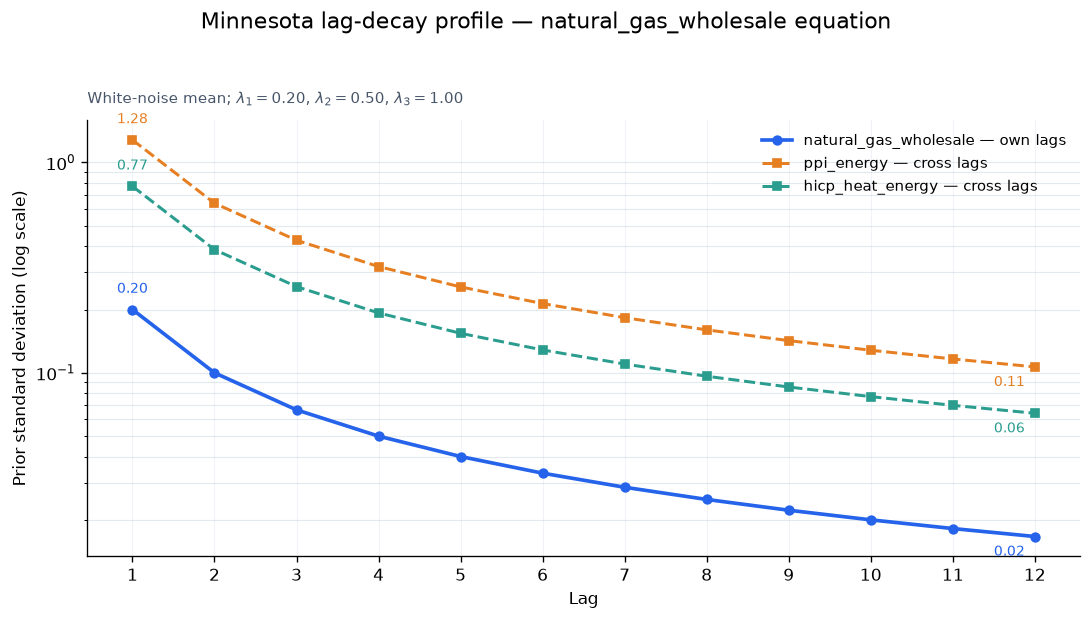

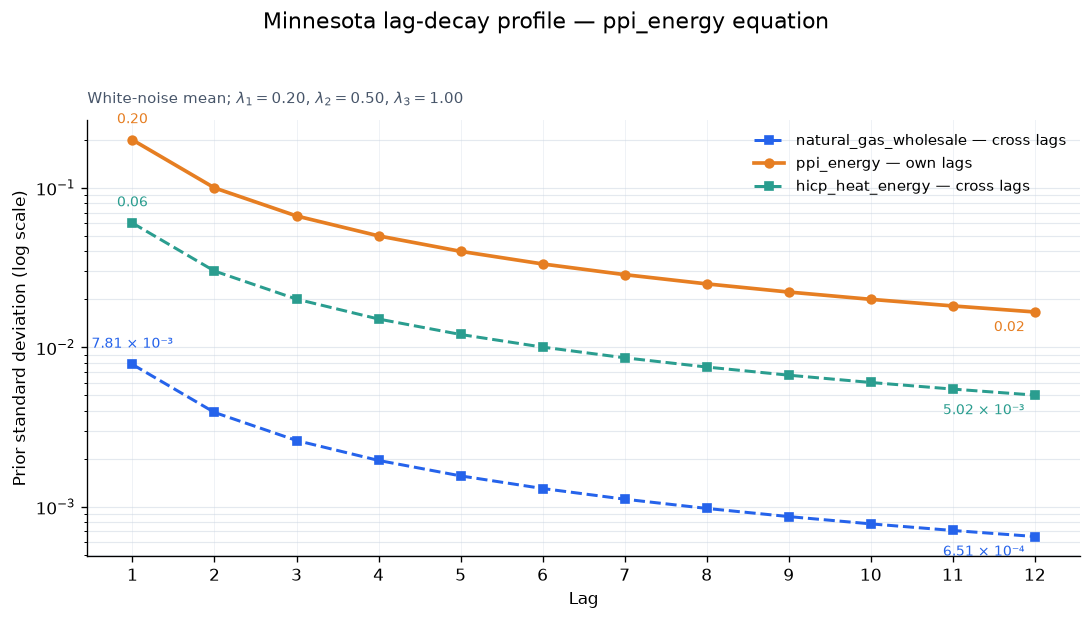

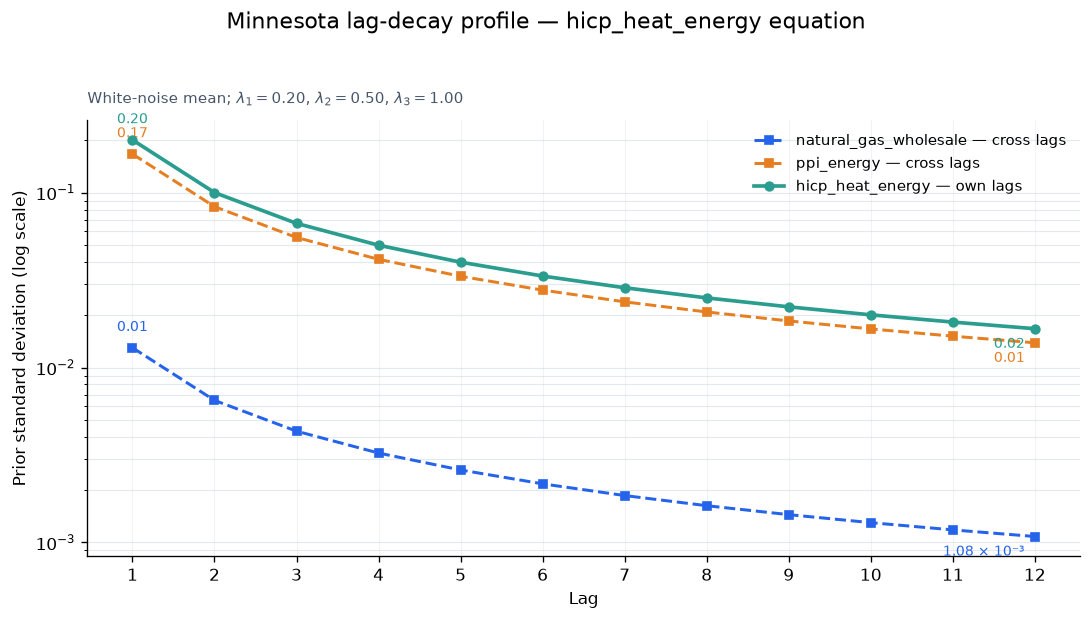

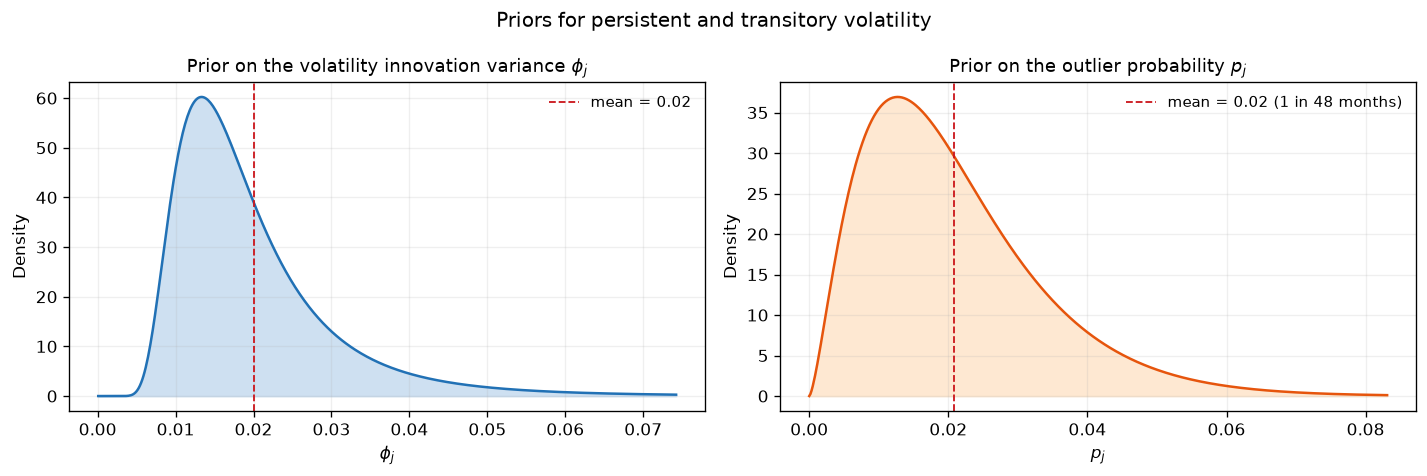

In [4]:
prior_config = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)
prior = make_bvar_svo_prior(prep, prior_config)

prior_table = pd.DataFrame({
    "value": [
        prior_config.lambda1,
        prior_config.lambda2,
        prior_config.lambda3,
        prior_config.lambda4,
        prior_config.a_prior_var,
        prior_config.phi_prior_mean,
        prior["outlier_alpha"],
        prior["outlier_beta"],
    ],
    "interpretation": [
        "overall Minnesota lag tightness",
        "additional cross-lag tightness",
        "lag-decay exponent",
        "constant prior scale",
        "variance of each free contemporaneous A coefficient",
        "prior mean of volatility-of-volatility variance",
        "Beta outlier pseudo-count",
        "Beta regular-observation pseudo-count",
    ],
}, index=[
    "lambda1", "lambda2", "lambda3", "lambda4",
    "A prior variance", "phi prior mean",
    "outlier alpha", "outlier beta",
])
display(style_numeric_table(prior_table, caption="Prior hyperparameters"))

prior_figures = plot_minnesota_prior_by_equation(prior, VARIABLES, P)
for equation, figure in prior_figures.items():
    display(figure)
    plt.close(figure)
plot_phi_and_outlier_priors(prior)
plt.show()

## 5. Posterior and Gibbs sampler

The coefficient block is drawn from its heteroskedastic Gaussian conditional and truncated to stable VAR dynamics. The contemporaneous matrix, complete stochastic-volatility paths, volatility innovation variances, outlier states and outlier probabilities are then updated conditionally inside each Gibbs iteration.

In [5]:
sampler_config = SamplerConfig(
    reps=6_000,
    burn=3_000,
    thin=1,
    seed=SEED,
    max_stability_tries=1_000,
    progress_every=500,
)

result = run_energy_bvar(
    levels=levels,
    model_id=COMPONENT,
    vintage=COMPONENT_DATASET.parent.name,
    p=P,
    variables=VARIABLES,
    prior_config=prior_config,
    sampler_config=sampler_config,
    code_version="energy_bvar_model-exog-v1",
)

print(f"Retained posterior draws: {result['n_draws']:,}")
print(f"Run ID: {result['metadata']['run_id']}")
print(f"B instability proposal rejection rate: {result['B_instability_rejection_rate']:.2%}")
display(style_numeric_table(
    pd.Series(dict(zip(VARIABLES, result["ksc_offsets"]))).to_frame("KSC offset"),
    caption="Adaptive KSC offsets",
))

if SAVE_RESULTS:
    saved_result_paths = save_energy_bvar_result(result, RESULTS_ROOT)
    print(f"Saved run: {saved_result_paths['directory']}")

iteration 500/6,000 | B instability rejection 0.00% | radius 0.8254
iteration 1,000/6,000 | B instability rejection 0.00% | radius 0.8342
iteration 1,500/6,000 | B instability rejection 0.00% | radius 0.8662
iteration 2,000/6,000 | B instability rejection 0.00% | radius 0.8580
iteration 2,500/6,000 | B instability rejection 0.00% | radius 0.8523
iteration 3,000/6,000 | B instability rejection 0.00% | radius 0.8369
iteration 3,500/6,000 | B instability rejection 0.00% | radius 0.8722
iteration 4,000/6,000 | B instability rejection 0.00% | radius 0.8538
iteration 4,500/6,000 | B instability rejection 0.00% | radius 0.8830
iteration 5,000/6,000 | B instability rejection 0.00% | radius 0.8601
iteration 5,500/6,000 | B instability rejection 0.00% | radius 0.8262
iteration 6,000/6,000 | B instability rejection 0.00% | radius 0.8304
Retained posterior draws: 3,000
Run ID: 674939338df9b9915ed10d2c180d65b9ea19d25318a40061f1ccd0811304bdb2
B instability proposal rejection rate: 0.00%


,KSC offset
natural_gas_wholesale,6.50 × 10⁻⁶
ppi_energy,5.98 × 10⁻⁸
hicp_heat_energy,8.56 × 10⁻⁸


## 6. Results

### 6.1 Posterior coefficients


natural_gas_wholesale equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,107.58,-0.12,-0.12,0.06,-0.22,-0.18,-0.05,-0.01,1580.48
natural_gas_wholesale L1,0.00,0.20,2.27 × 10⁻³,2.24 × 10⁻³,0.06,-0.09,-0.06,0.06,0.10,610.91
ppi_energy L1,0.00,1.28,0.47,0.48,0.22,0.10,0.25,0.69,0.84,882.51
hicp_heat_energy L1,0.00,0.77,-0.14,-0.15,0.17,-0.40,-0.30,0.03,0.14,715.16
natural_gas_wholesale L2,0.00,0.10,-0.03,-0.03,0.05,-0.11,-0.08,0.01,0.05,1690.71
ppi_energy L2,0.00,0.64,0.32,0.33,0.22,-0.04,0.11,0.54,0.67,1427.04
hicp_heat_energy L2,0.00,0.39,-0.07,-0.07,0.13,-0.30,-0.21,0.06,0.14,1380.94
natural_gas_wholesale L3,0.00,0.07,0.07,0.07,0.04,3.43 × 10⁻³,0.03,0.12,0.15,852.44
ppi_energy L3,0.00,0.43,0.34,0.34,0.20,0.01,0.14,0.54,0.67,1592.11


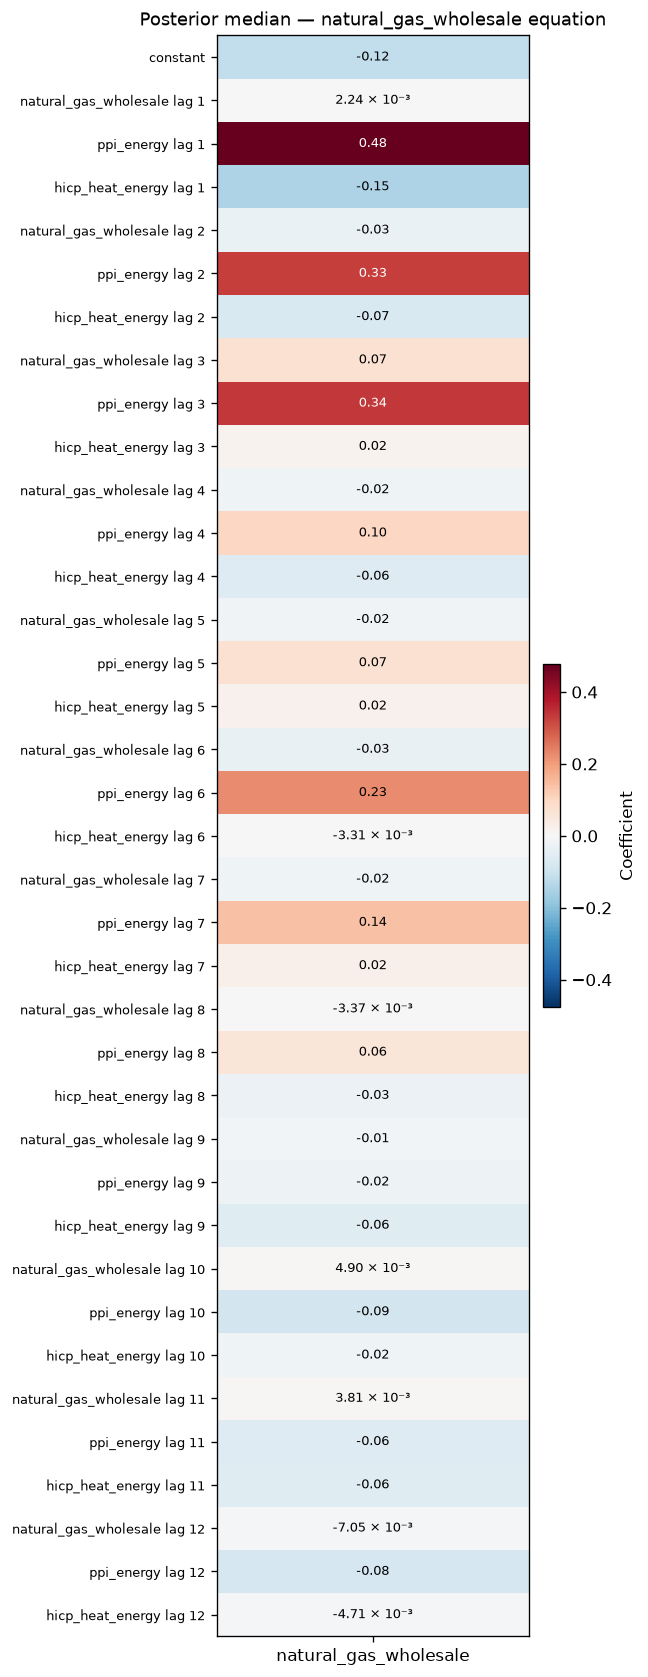

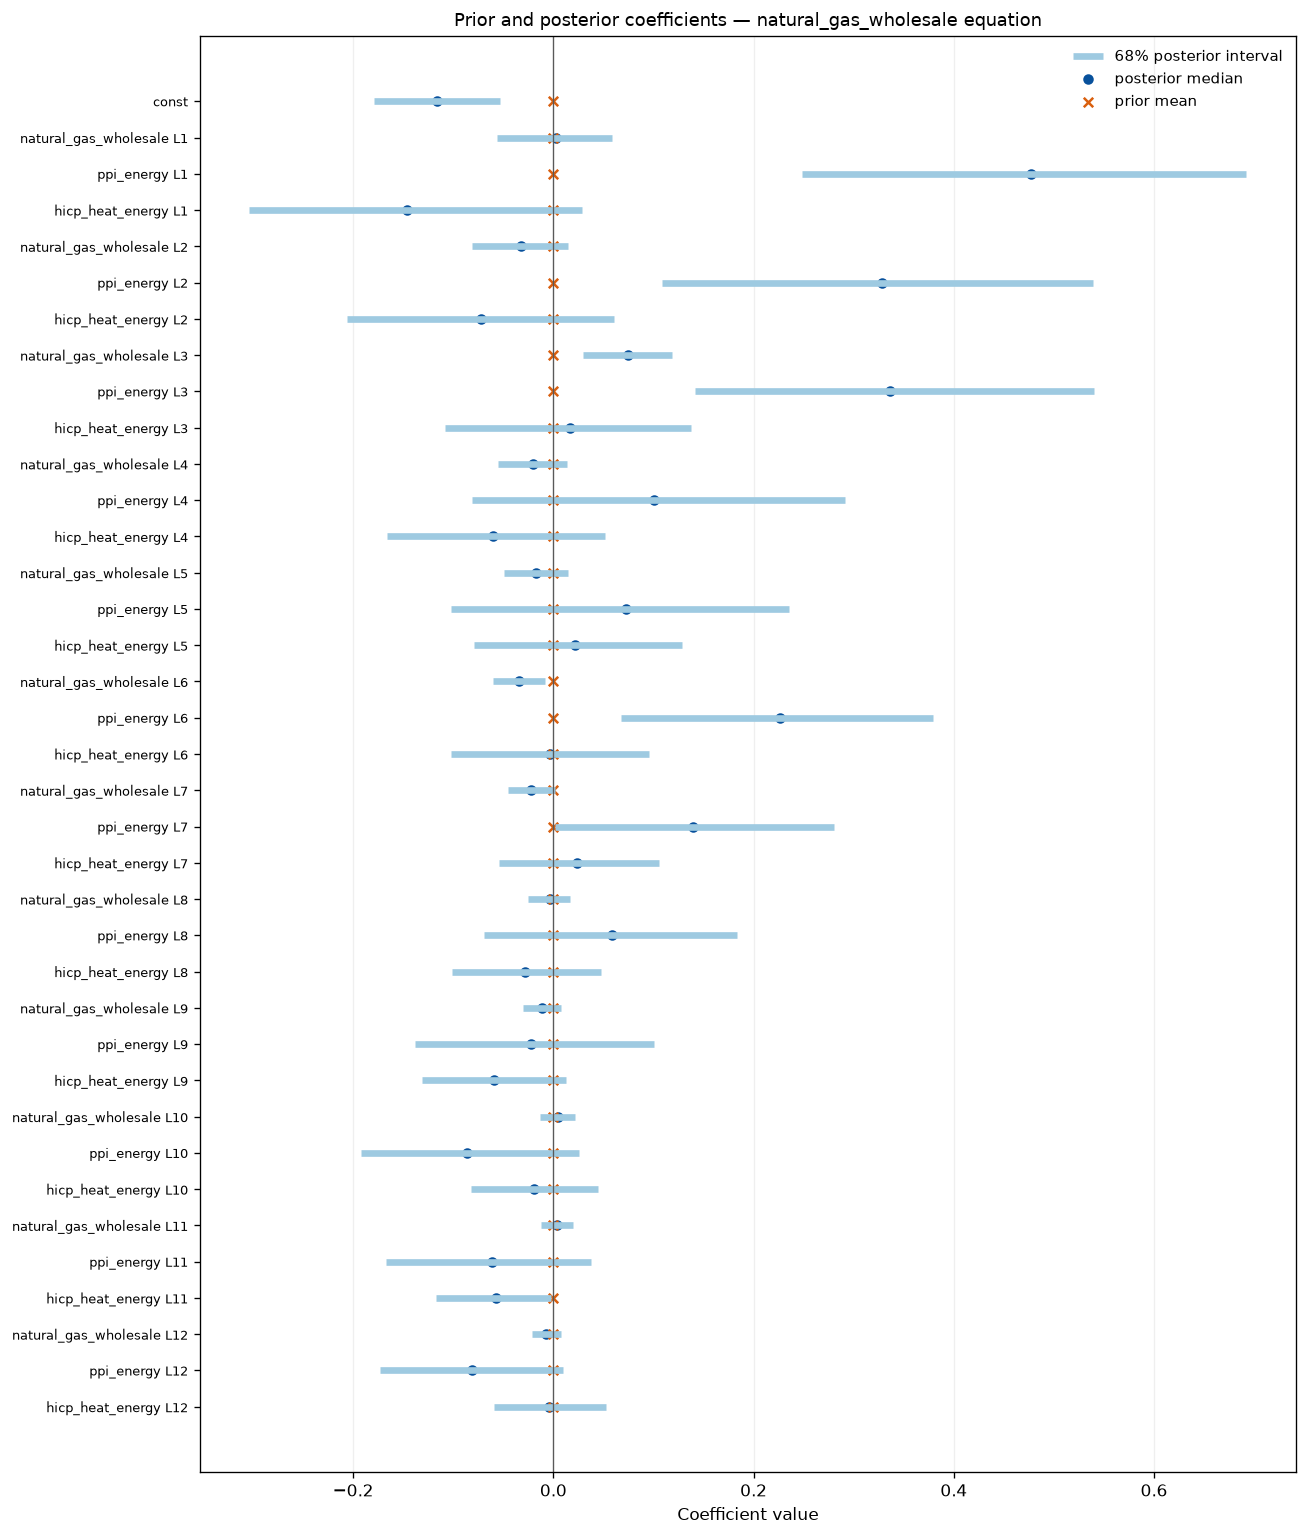


ppi_energy equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,8.40,0.04,0.04,0.02,0.01,0.02,0.06,0.07,1965.52
natural_gas_wholesale L1,0.00,7.81 × 10⁻³,7.60 × 10⁻³,7.63 × 10⁻³,5.13 × 10⁻³,-8.37 × 10⁻⁴,2.54 × 10⁻³,0.01,0.02,1286.38
ppi_energy L1,0.00,0.20,0.46,0.46,0.05,0.38,0.41,0.51,0.54,1912.74
hicp_heat_energy L1,0.00,0.06,0.06,0.06,0.03,2.27 × 10⁻³,0.02,0.09,0.11,657.58
natural_gas_wholesale L2,0.00,3.91 × 10⁻³,-4.31 × 10⁻⁴,-4.64 × 10⁻⁴,3.42 × 10⁻³,-6.12 × 10⁻³,-3.80 × 10⁻³,3.02 × 10⁻³,5.29 × 10⁻³,2323.56
ppi_energy L2,0.00,0.10,0.04,0.04,0.05,-0.04,-5.70 × 10⁻³,0.09,0.12,660.67
hicp_heat_energy L2,0.00,0.03,-0.03,-0.03,0.02,-0.07,-0.06,-0.01,1.55 × 10⁻³,2499.43
natural_gas_wholesale L3,0.00,2.60 × 10⁻³,2.47 × 10⁻³,2.51 × 10⁻³,2.47 × 10⁻³,-1.54 × 10⁻³,6.16 × 10⁻⁶,4.88 × 10⁻³,6.54 × 10⁻³,2674.44
ppi_energy L3,0.00,0.07,0.09,0.09,0.04,0.02,0.05,0.13,0.16,2276.04


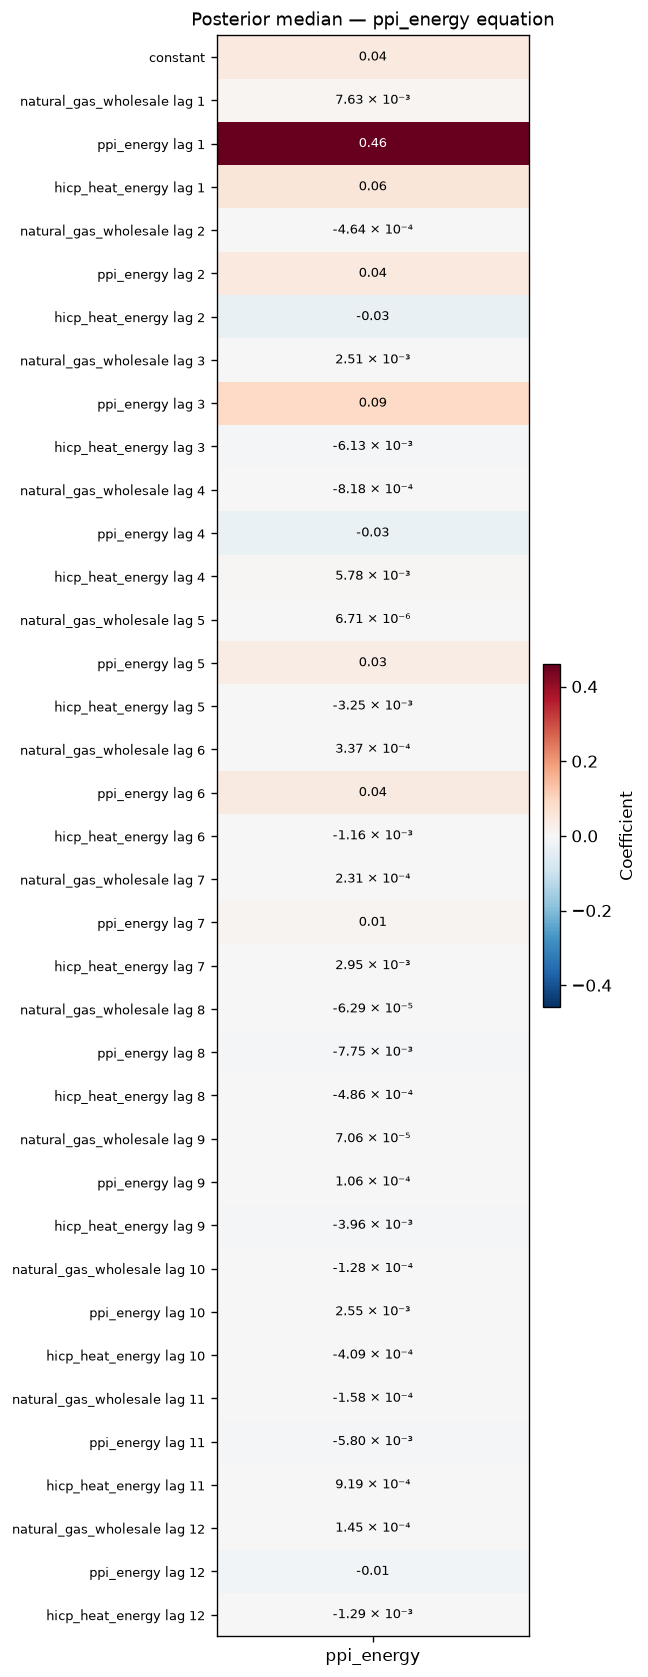

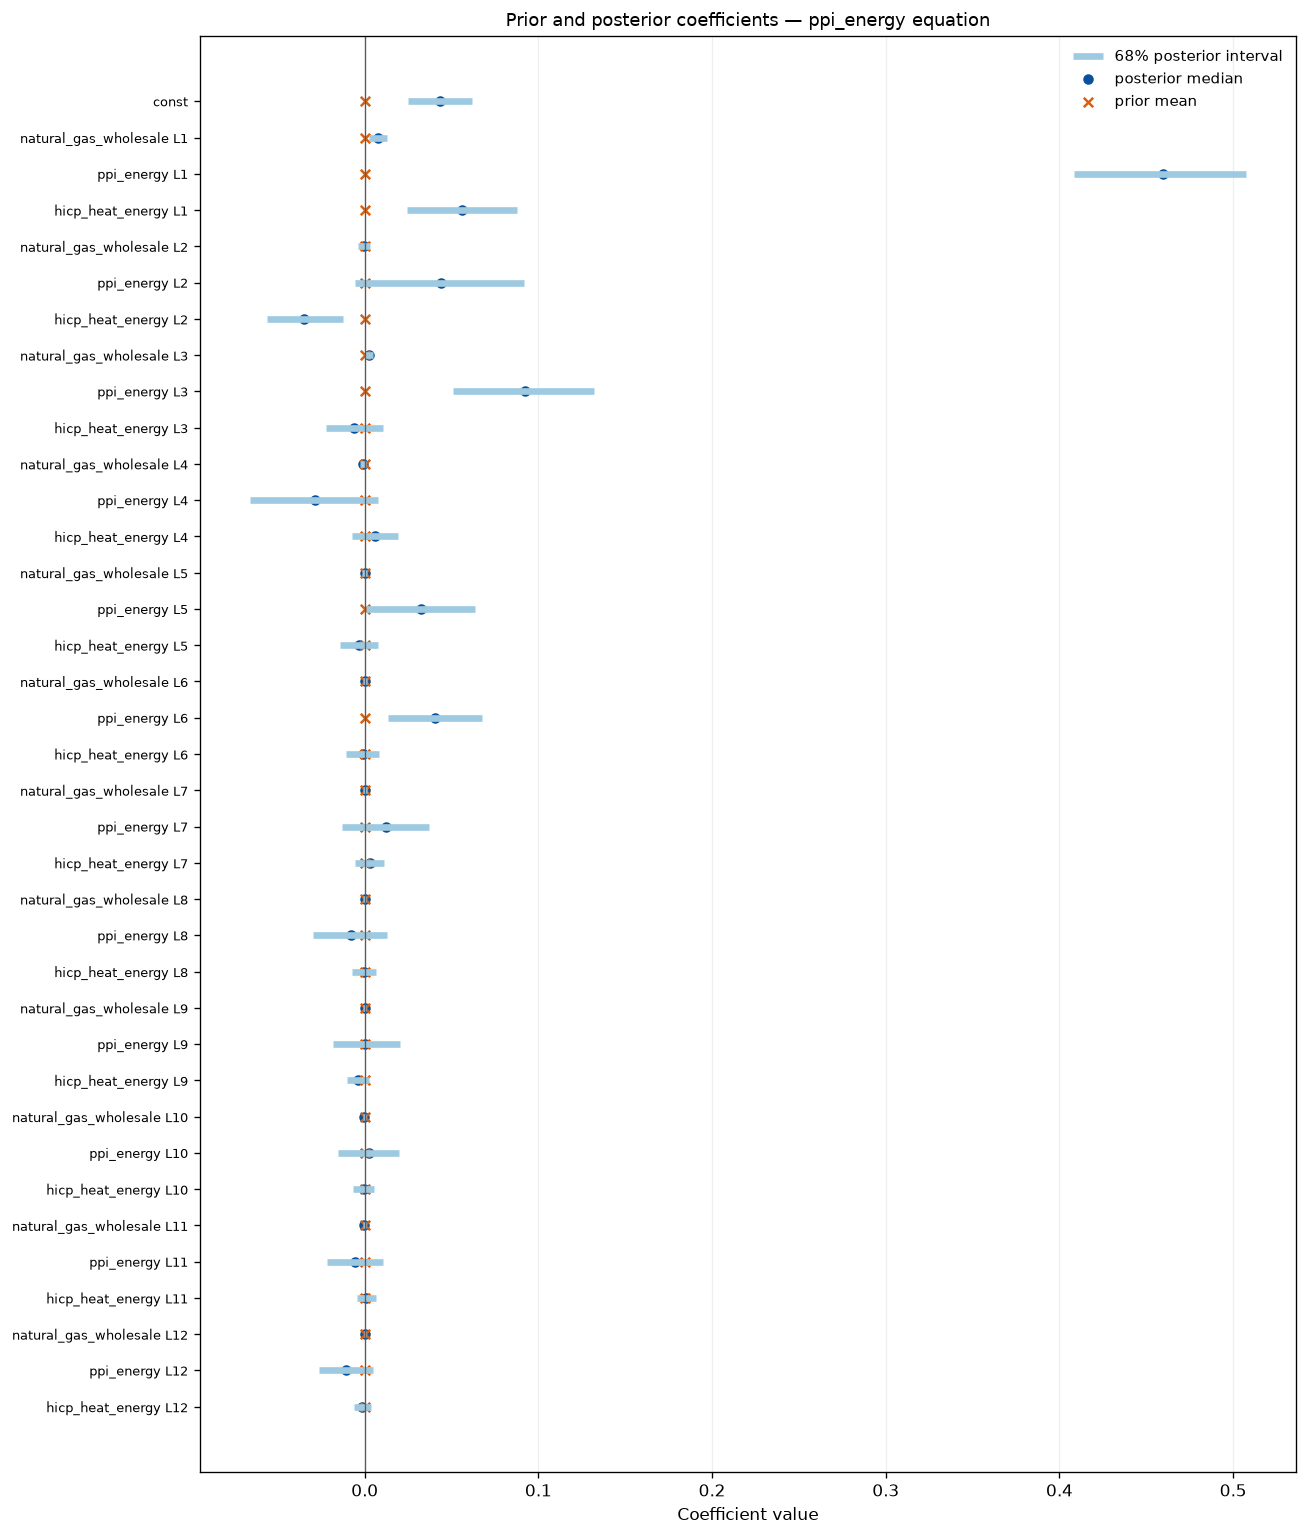


hicp_heat_energy equation


,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
regressor,,,,,,,,,,
const,0.00,13.96,1.13 × 10⁻⁴,-6.49 × 10⁻⁵,0.01,-0.02,-0.01,0.01,0.02,1285.14
natural_gas_wholesale L1,0.00,0.01,5.41 × 10⁻³,5.40 × 10⁻³,3.60 × 10⁻³,-3.37 × 10⁻⁴,1.81 × 10⁻³,8.94 × 10⁻³,0.01,2321.01
ppi_energy L1,0.00,0.17,0.06,0.05,0.04,-5.39 × 10⁻³,0.02,0.09,0.12,1628.84
hicp_heat_energy L1,0.00,0.20,0.08,0.08,0.03,0.03,0.05,0.11,0.13,917.89
natural_gas_wholesale L2,0.00,6.49 × 10⁻³,0.01,0.01,4.35 × 10⁻³,5.27 × 10⁻³,8.12 × 10⁻³,0.02,0.02,1131.21
ppi_energy L2,0.00,0.08,0.02,0.02,0.04,-0.04,-0.02,0.06,0.08,996.75
hicp_heat_energy L2,0.00,0.10,0.15,0.15,0.02,0.11,0.12,0.17,0.18,1871.62
natural_gas_wholesale L3,0.00,4.33 × 10⁻³,3.98 × 10⁻³,4.02 × 10⁻³,3.43 × 10⁻³,-1.57 × 10⁻³,5.31 × 10⁻⁴,7.50 × 10⁻³,9.52 × 10⁻³,2230.72
ppi_energy L3,0.00,0.06,0.09,0.09,0.03,0.04,0.06,0.12,0.14,2192.48


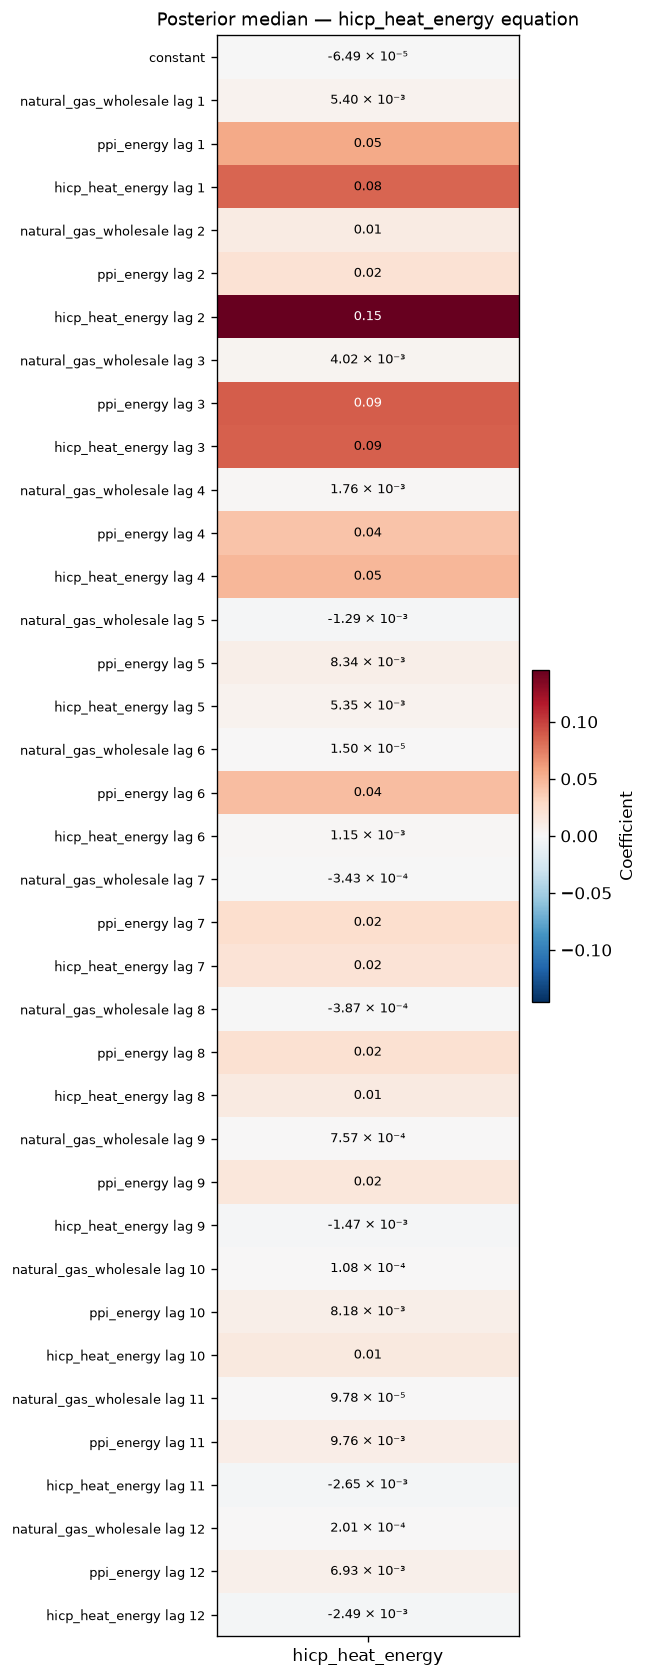

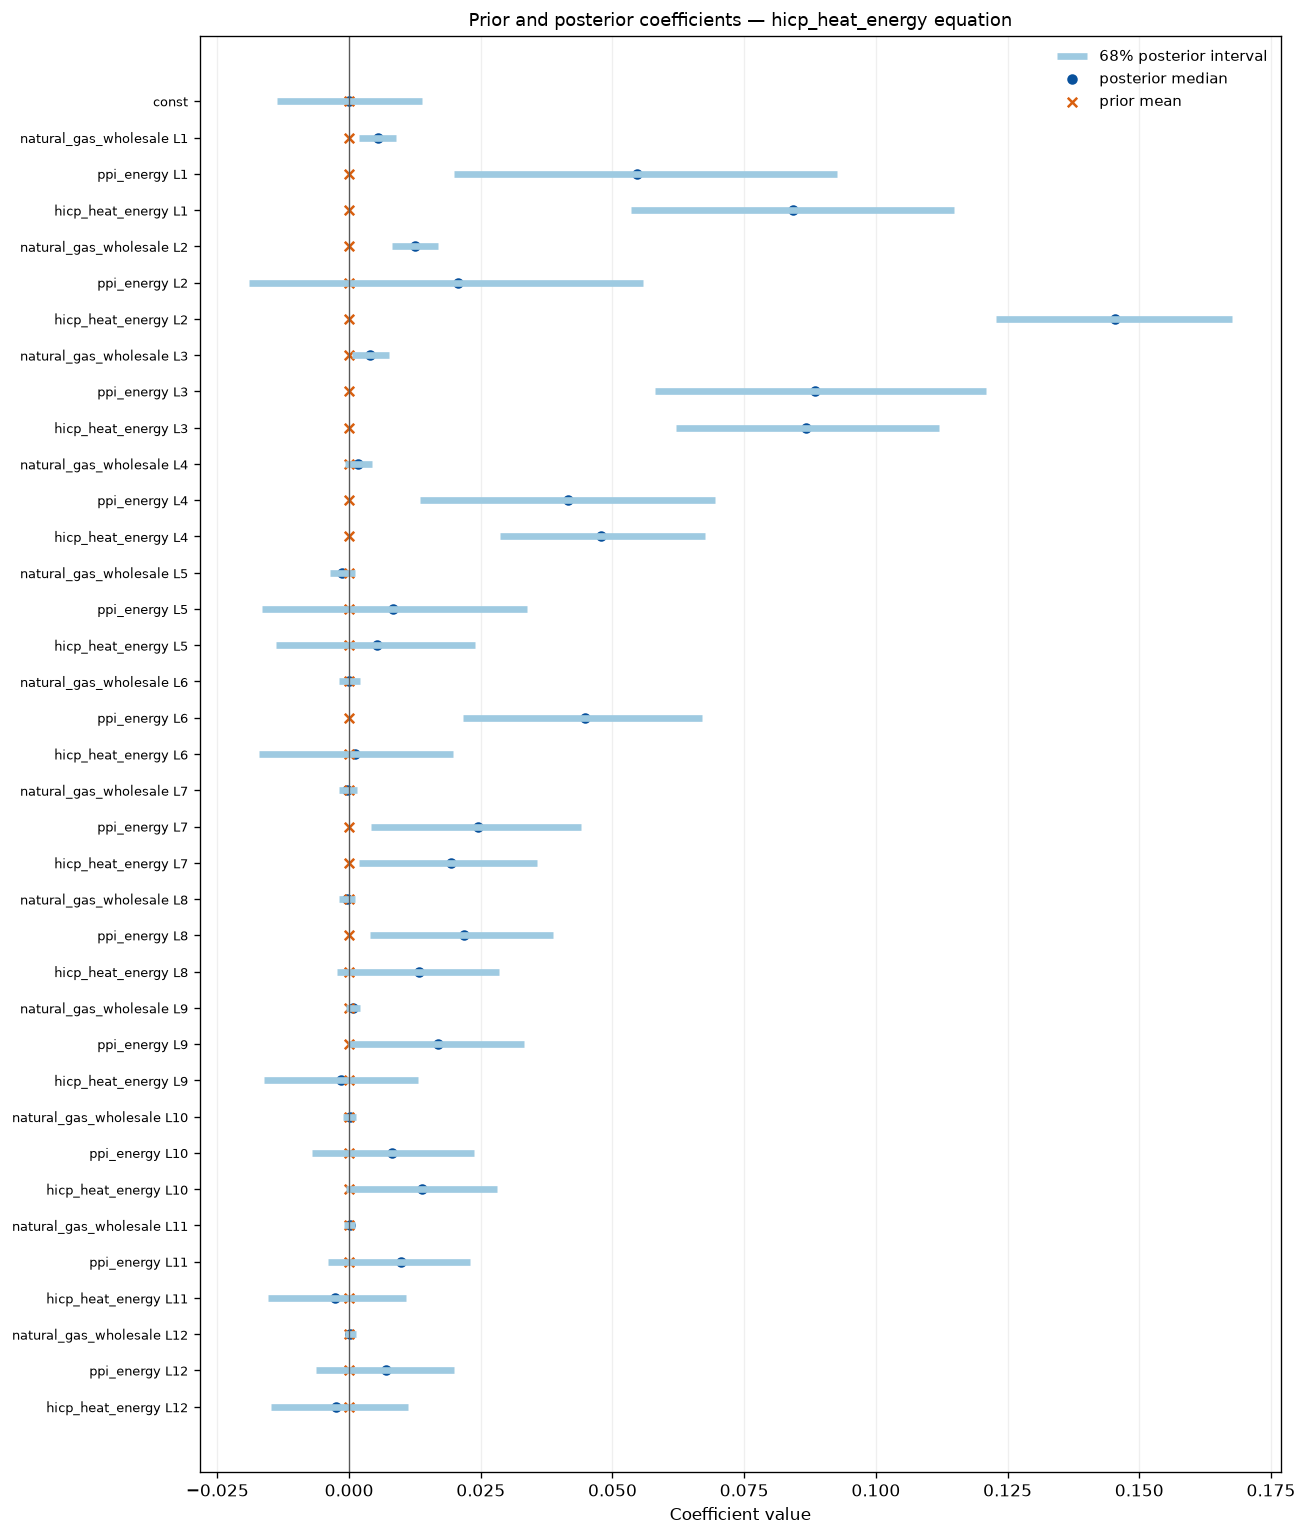

In [6]:
coefficient_tables = coefficient_posterior_tables(result)
for equation in VARIABLES:
    print()
    print(f"{equation} equation")
    display(style_numeric_table(
        coefficient_tables[equation],
        caption=f"Posterior coefficients — {equation} equation",
    ))
    plot_coefficient_heatmap(result, equation=equation)
    plot_shrinkage_comparison(result, equations=[equation])
    plt.show()

### 6.2 Stochastic volatility and transitory outliers

,,posterior_probability
date,,
2001-08-01,hicp_heat_energy,1.00
2023-01-01,hicp_heat_energy,1.00
2016-10-01,hicp_heat_energy,1.00
2008-10-01,hicp_heat_energy,1.00
2006-04-01,hicp_heat_energy,1.00
2022-12-01,hicp_heat_energy,1.00
2005-10-01,hicp_heat_energy,1.00
2006-10-01,hicp_heat_energy,1.00
2016-05-01,hicp_heat_energy,1.00


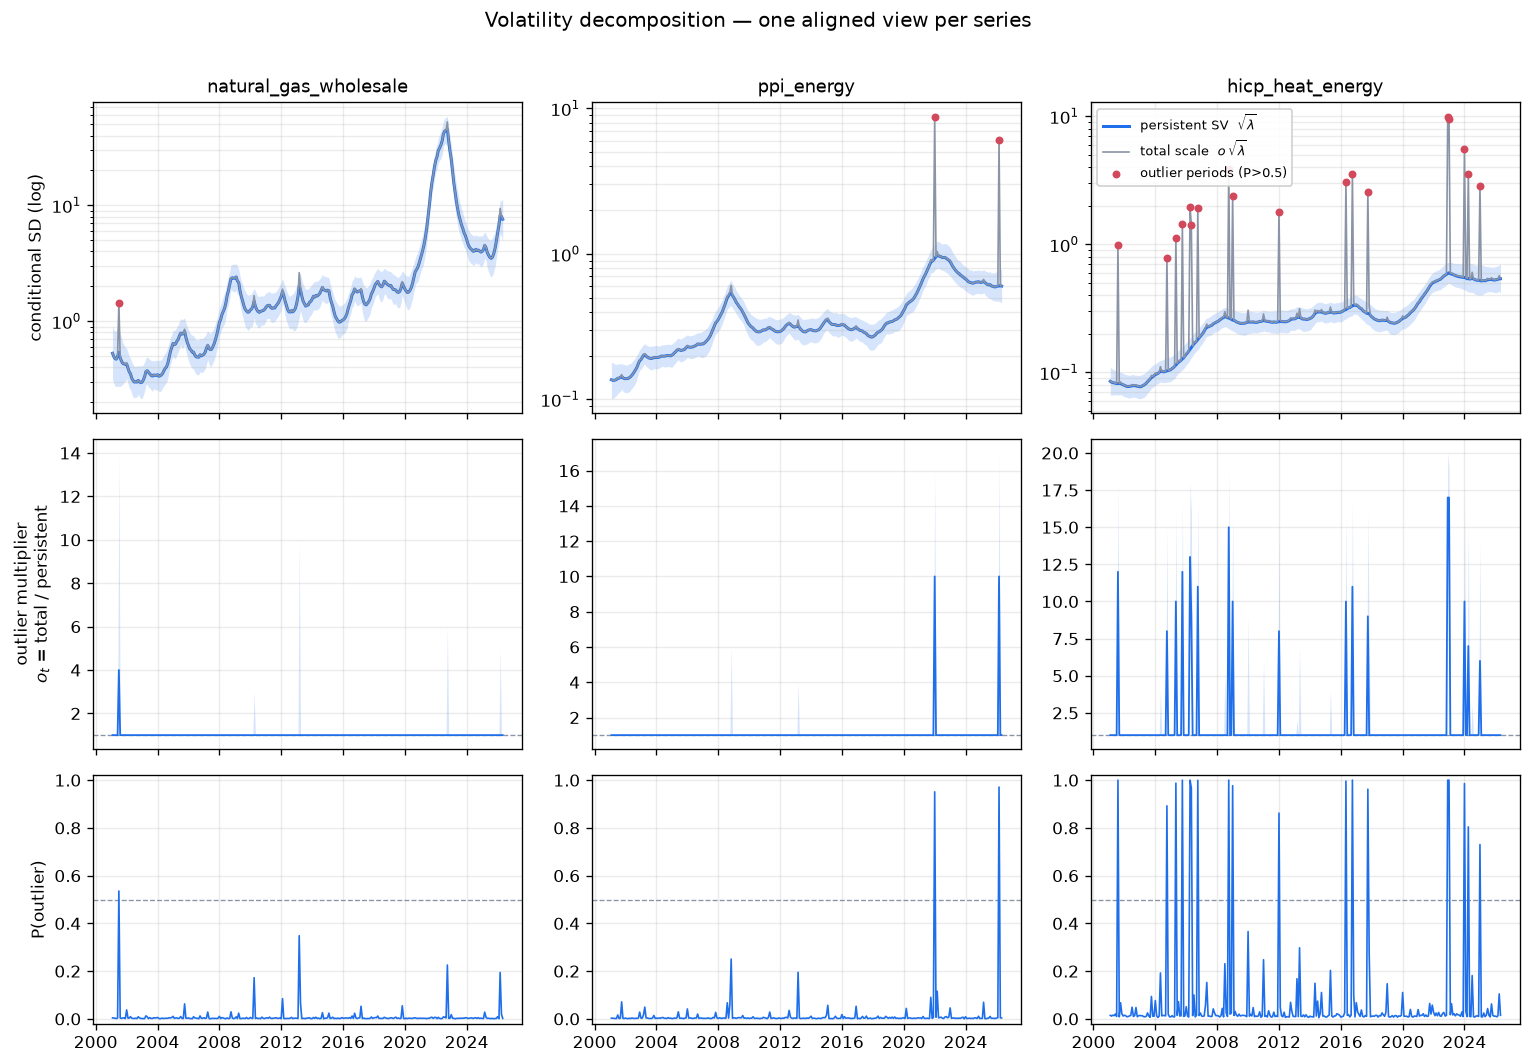

In [7]:
outlier_probability = posterior_outlier_probability(result)
important_outliers = (
    outlier_probability.stack()
    .rename("posterior_probability")
    .loc[lambda series: series >= 0.50]
    .sort_values(ascending=False)
    .to_frame()
)
display(style_numeric_table(
    important_outliers.head(30),
    caption="Dates with posterior outlier probability at least 50%",
))
plot_volatility_decomposition(result)
plt.show()

### 6.3 Standardized structural residuals

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
natural_gas_wholesale,0.04,0.94,0.06,-0.06,9.51 × 10⁻³,2.93
ppi_energy,1.57 × 10⁻³,0.98,-0.17,0.31,0.01,2.98
hicp_heat_energy,0.09,0.97,-0.16,0.38,0.04,2.76


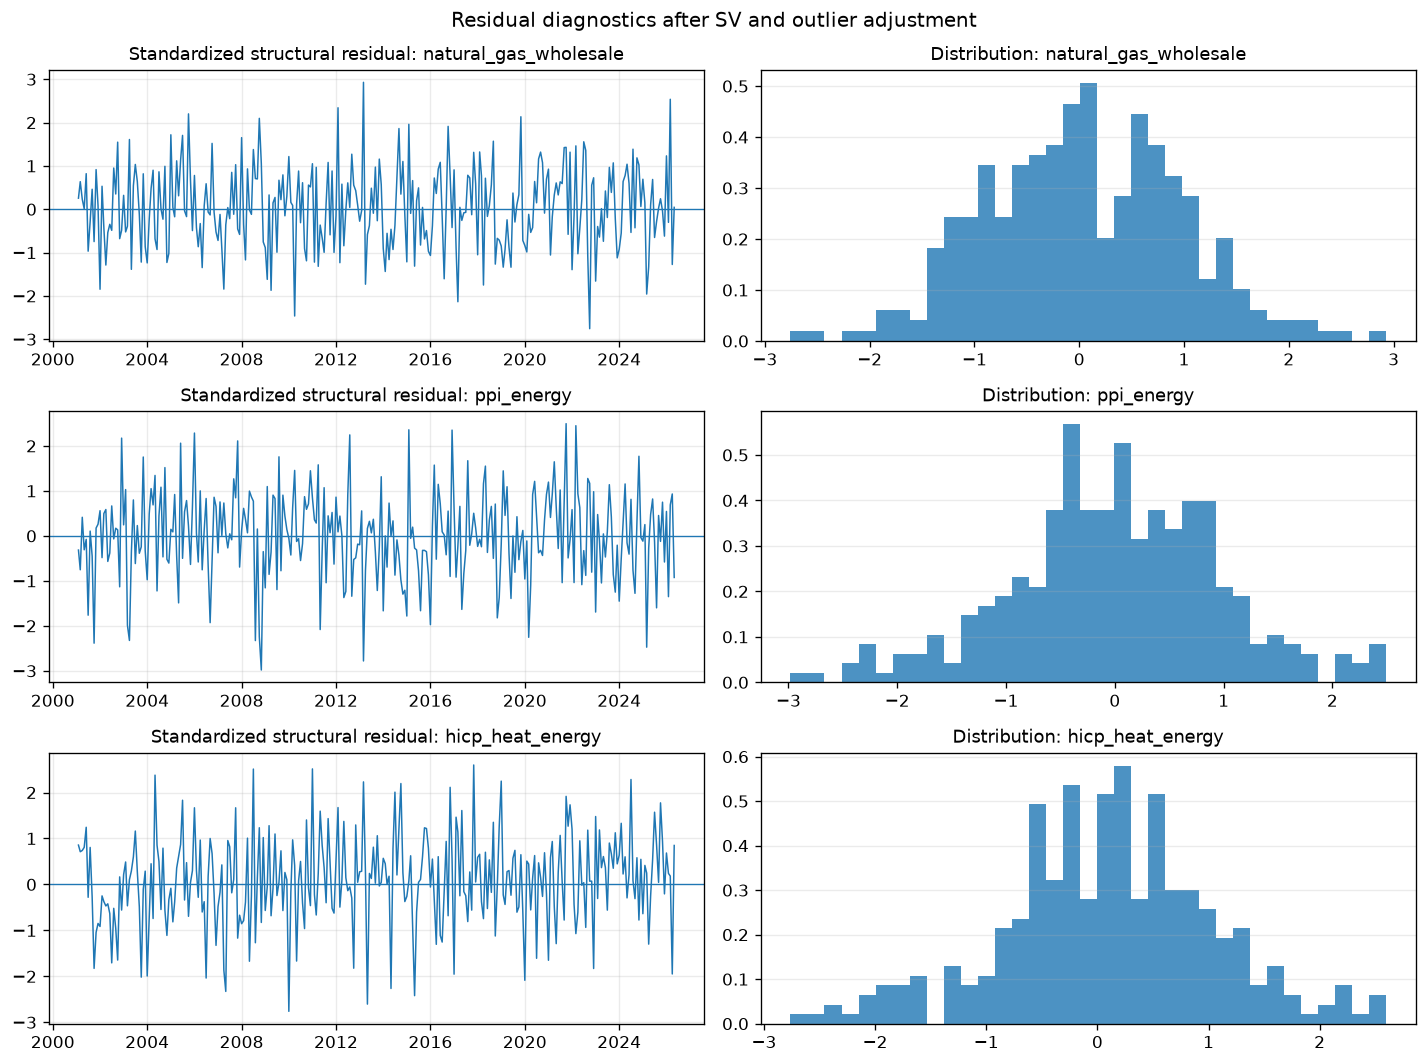

In [8]:
display(style_numeric_table(
    residual_diagnostic_table(result),
    caption="Standardized structural-residual diagnostics",
))
plot_standardized_residuals(result)
plt.show()

## 7. Ragged-edge nowcast and forecasts

Forecast origin: 2026-08-01
Forecast horizon used: 4 months


,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-07-01,nowcast,—,100.84,103.76,104.94,106.03,108.36
2026-08-01,nowcast,—,95.75,102.43,105.55,108.29,114.31


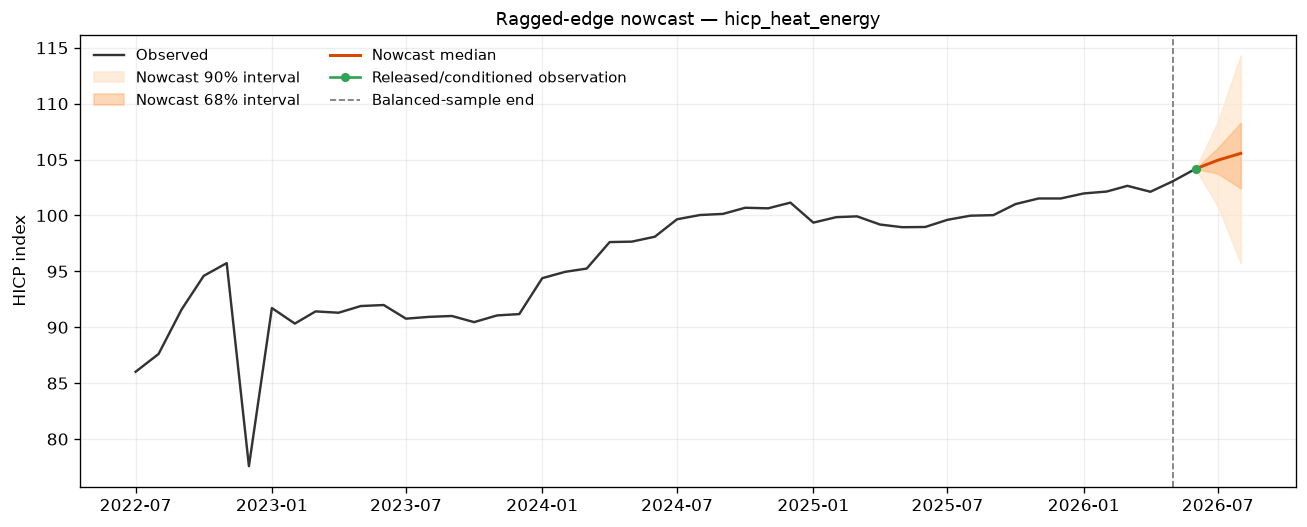

In [9]:
FORECAST_ORIGIN = prep["last_calendar_date"]
MONTHS_TO_YEAR_END = 12 - FORECAST_ORIGIN.month
if MONTHS_TO_YEAR_END == 0:
    MONTHS_TO_YEAR_END = 12
H = max(3, MONTHS_TO_YEAR_END)
FORECAST_DRAWS = min(1_000, result["n_draws"])

forecast_unconditional = forecast_bvar_sv_outlier(
    result,
    H=H,
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

print(f"Forecast origin: {FORECAST_ORIGIN.date()}")
print(f"Forecast horizon used: {H} months")

nowcast_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=levels,
    variable=TARGET,
    missing_only=True,
)
if nowcast_table.empty:
    print(f"No missing {TARGET} observation is present in the ragged edge.")
else:
    display(style_numeric_table(
        nowcast_table,
        caption=f"Ragged-edge nowcast — {TARGET}",
    ))
plot_nowcast_fan(
    forecast_unconditional,
    historical_levels=levels,
    variable=TARGET,
    ylabel=UNITS[TARGET],
)
plt.show()

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,22.29,45.12,58.71,71.70,89.83
3 months,3.00,2026-11-01,12.95,42.90,62.28,83.33,108.46
End of 2026,4.00,2026-12-01,0.17,38.86,62.92,86.67,120.87


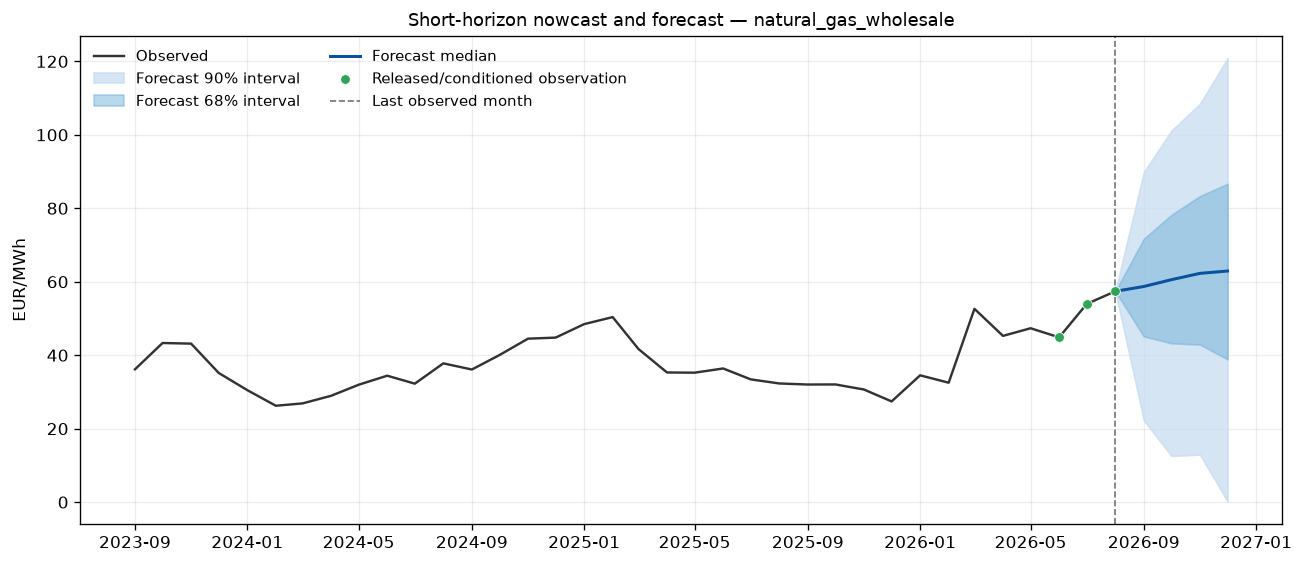

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,118.88,130.02,135.47,142.45,151.79
3 months,3.00,2026-11-01,112.92,129.17,137.15,145.76,159.94
End of 2026,4.00,2026-12-01,110.95,128.14,137.65,147.76,162.04


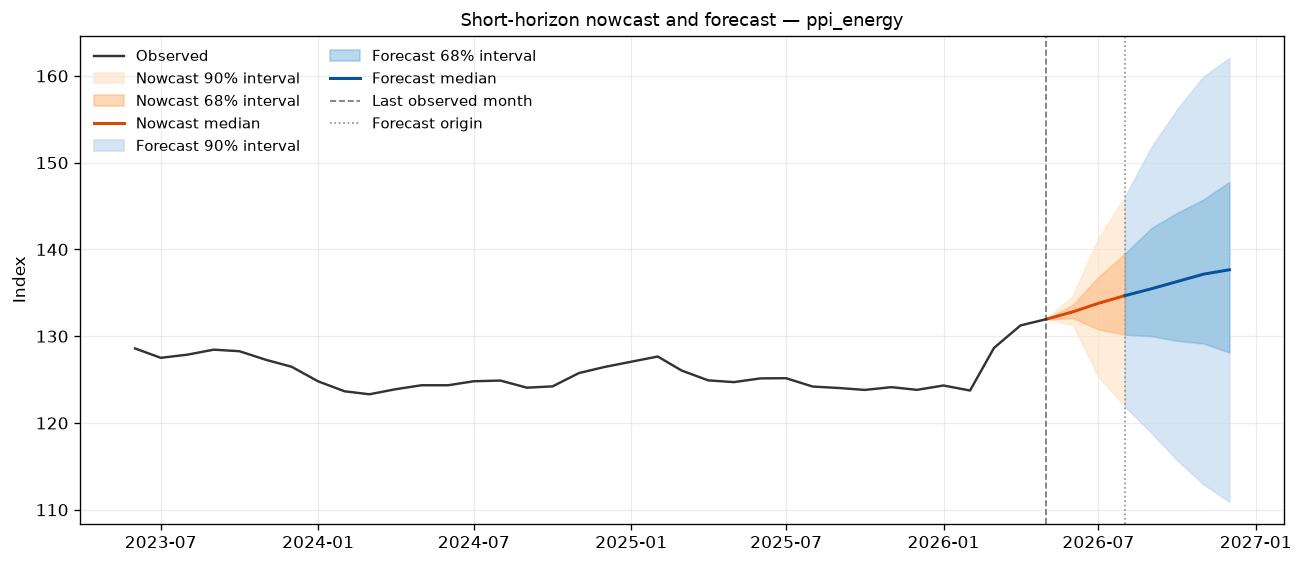

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,91.80,101.15,106.44,110.42,119.36
3 months,3.00,2026-11-01,85.31,99.95,107.88,114.75,127.10
End of 2026,4.00,2026-12-01,83.70,99.33,108.73,116.92,130.77


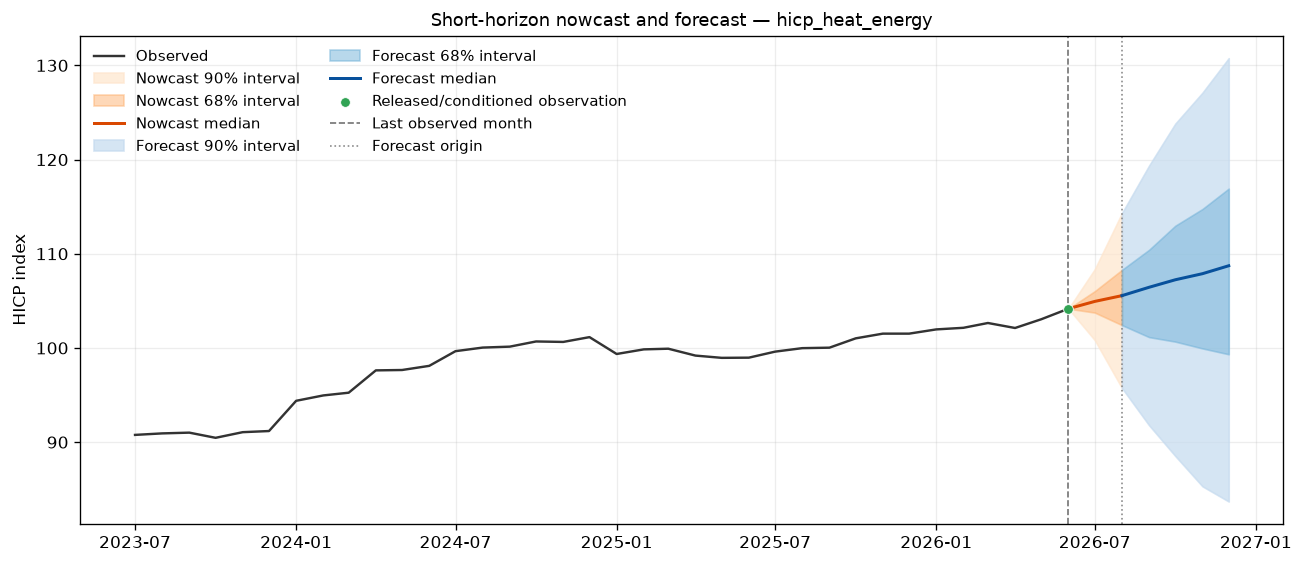

In [10]:
for variable in VARIABLES:
    table = forecast_horizon_table(forecast_unconditional, variable)
    display(style_numeric_table(
        table,
        caption=f"Unconditional level forecast — {variable} ({UNITS[variable]})",
    ))
    plot_short_forecast_fan(
        forecast_unconditional,
        historical_levels=levels,
        variable=variable,
        ylabel=UNITS[variable],
    )
    plt.show()

### 7.1 Conditional wholesale-gas scenario

The future wholesale natural-gas level is fixed at 10% above its latest observed value. This is a scenario comparison; the other variables remain unconstrained.

Maximum absolute wholesale-gas condition error: 2.13 × 10⁻¹²


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,91.82,101.39,106.46,110.54,119.74
3 months,3.00,2026-11-01,86.28,100.24,107.98,114.38,127.42
End of 2026,4.00,2026-12-01,84.74,100.21,108.73,116.37,129.89


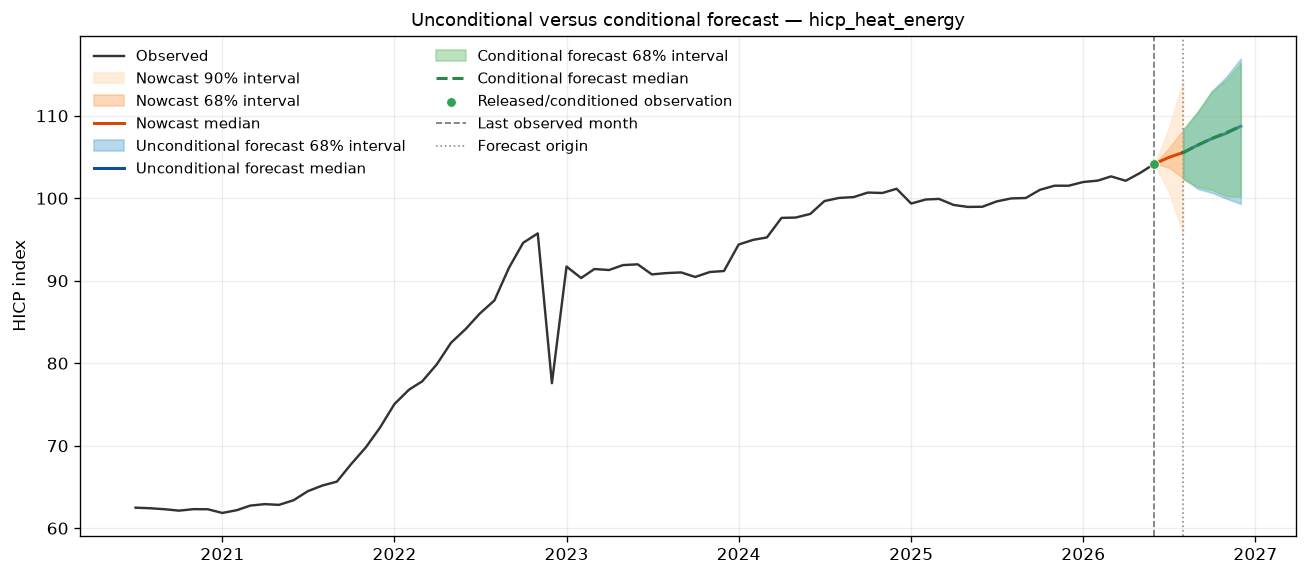

In [11]:
last_wholesale_level = levels["natural_gas_wholesale"].dropna().iloc[-1]
wholesale_up_10 = np.full(H, 1.10 * last_wholesale_level)

forecast_gas_up_10 = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={"natural_gas_wholesale": wholesale_up_10},
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

condition_error = np.max(np.abs(
    forecast_gas_up_10["future_level_paths"][:, :, VARIABLES.index("natural_gas_wholesale")]
    - wholesale_up_10[None, :]
))
print(f"Maximum absolute wholesale-gas condition error: {format_number(condition_error)}")

display(style_numeric_table(
    forecast_horizon_table(forecast_gas_up_10, TARGET),
    caption=f"Conditional {TARGET} forecast — wholesale gas +10%",
))
plot_forecast_comparison(
    forecast_unconditional,
    forecast_gas_up_10,
    historical_levels=levels,
    variable=TARGET,
    ylabel=UNITS[TARGET],
)
plt.show()

### 7.2 Conditional PPI Energy scenario

The future PPI Energy level is fixed at 10% above its latest observed value, while wholesale gas and the HICP target remain unconstrained.

In [12]:
import inspect

print("Fonction chargée depuis :")
print(inspect.getsourcefile(forecast_bvar_sv_outlier))

model_levels = result["prep"]["levels"]

print("\nDernière date calendaire :", model_levels.index[-1])
print(
    "Dernière date observée pour PPI :",
    model_levels["ppi_energy"].last_valid_index(),
)
print(
    "Valeur PPI à la dernière date calendaire :",
    model_levels["ppi_energy"].iloc[-1],
)

display(model_levels.tail(12))

Fonction chargée depuis :
C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\src\model\energy_bvar_model.py

Dernière date calendaire : 2026-08-01 00:00:00
Dernière date observée pour PPI : 2026-05-01 00:00:00
Valeur PPI à la dernière date calendaire : nan


,natural_gas_wholesale,ppi_energy,hicp_heat_energy
date,,,
2025-09-01,32.017500,124.03,100.03
2025-10-01,32.043174,123.81,101.02
2025-11-01,30.657000,124.13,101.52
2025-12-01,27.422478,123.82,101.52
2026-01-01,34.524318,124.32,101.97
2026-02-01,32.513750,123.74,102.14
2026-03-01,52.626909,128.65,102.65
2026-04-01,45.264500,131.24,102.12
2026-05-01,47.341286,131.96,103.05


Maximum absolute PPI condition error: 1.25 × 10⁻¹²


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,95.43,103.68,107.70,112.19,127.88
3 months,3.00,2026-11-01,91.94,104.41,110.45,116.55,135.07
End of 2026,4.00,2026-12-01,91.80,104.84,111.70,118.80,138.44


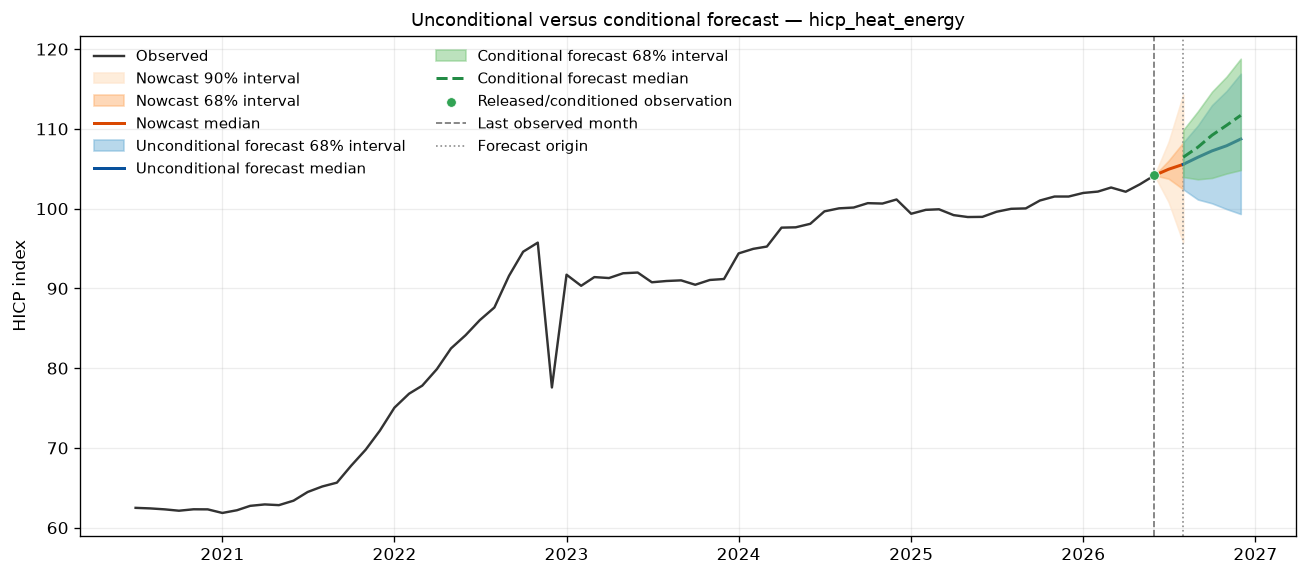

In [13]:
last_ppi_level = levels["ppi_energy"].dropna().iloc[-1]
ppi_up_10 = np.full(H, 1.10 * last_ppi_level)

forecast_ppi_up_10 = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={"ppi_energy": ppi_up_10},
    n_draws=FORECAST_DRAWS,
    simulate_future_outliers=True,
    seed=2026,
)

condition_error = np.max(np.abs(
    forecast_ppi_up_10["future_level_paths"][:, :, VARIABLES.index("ppi_energy")]
    - ppi_up_10[None, :]
))
print(f"Maximum absolute PPI condition error: {format_number(condition_error)}")

display(style_numeric_table(
    forecast_horizon_table(forecast_ppi_up_10, TARGET),
    caption=f"Conditional {TARGET} forecast — PPI Energy +10%",
))
plot_forecast_comparison(
    forecast_unconditional,
    forecast_ppi_up_10,
    historical_levels=levels,
    variable=TARGET,
    ylabel=UNITS[TARGET],
)
plt.show()

### 7.3 HICP heat energy level and year-on-year inflation

,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,91.80,101.15,106.44,110.42,119.36
3 months,3.00,2026-11-01,85.31,99.95,107.88,114.75,127.10
End of 2026,4.00,2026-12-01,83.70,99.33,108.73,116.92,130.77


,months_ahead,target_date,q05,q16,median,q84,q95
horizon,,,,,,,
1 month,1.00,2026-09-01,-8.23,1.12,6.41,10.39,19.32
3 months,3.00,2026-11-01,-15.97,-1.55,6.27,13.04,25.20
End of 2026,4.00,2026-12-01,-17.55,-2.16,7.10,15.17,28.81


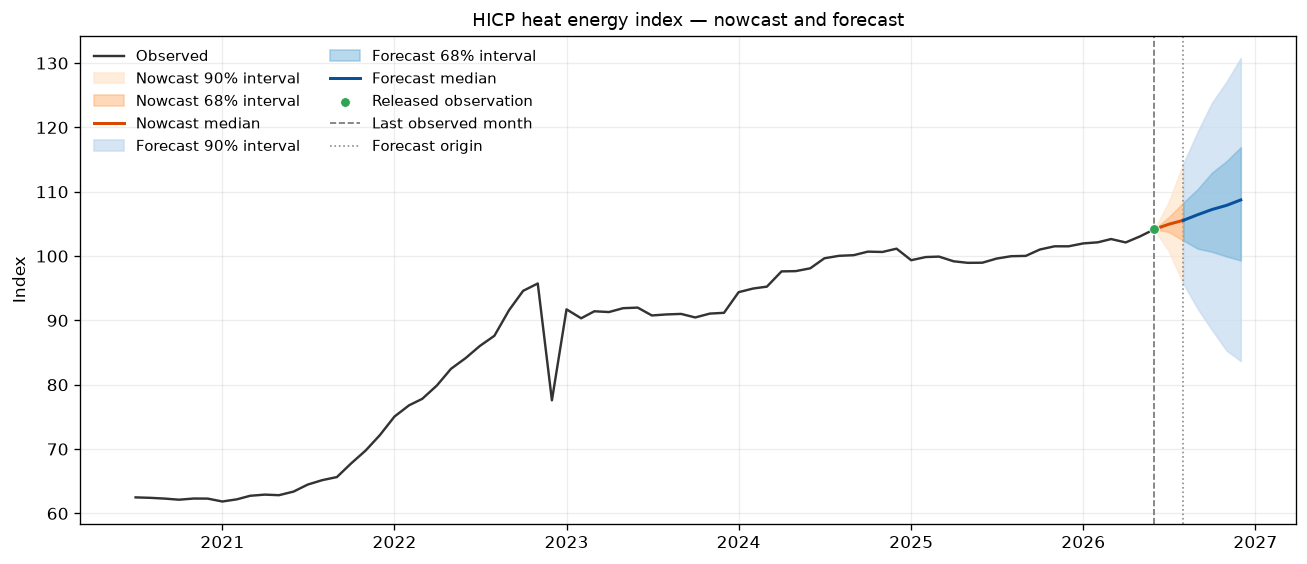

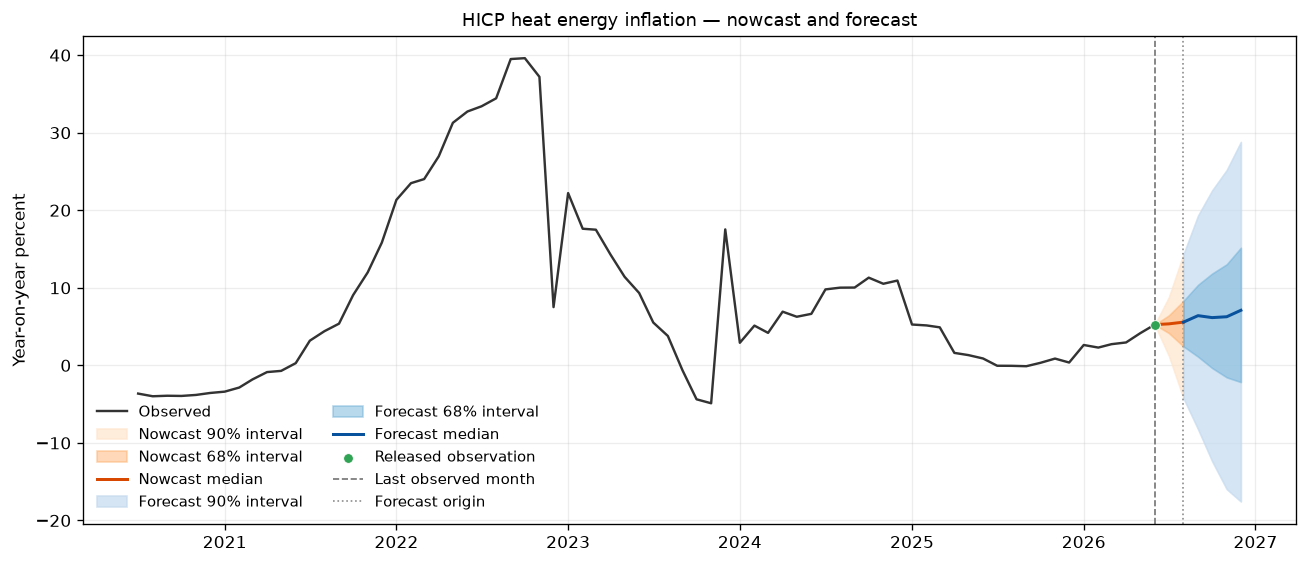

In [14]:
hicp_unconditional = forecast_hicp_component(
    forecast_unconditional,
    result,
    component=COMPONENT,
)
hicp_gas_up_10 = forecast_hicp_component(
    forecast_gas_up_10,
    result,
    component=COMPONENT,
)
hicp_ppi_up_10 = forecast_hicp_component(
    forecast_ppi_up_10,
    result,
    component=COMPONENT,
)

display(style_numeric_table(
    path_horizon_table(
        hicp_unconditional["future_hicp_level_paths"],
        hicp_unconditional["future_dates"],
        forecast_unconditional["last_calendar_date"],
    ),
    caption=f"HICP {SPEC['label']} index forecast",
))
display(style_numeric_table(
    path_horizon_table(
        hicp_unconditional["future_hicp_yoy_paths"],
        hicp_unconditional["future_dates"],
        forecast_unconditional["last_calendar_date"],
    ),
    caption=f"HICP {SPEC['label']} year-on-year inflation forecast (%)",
))

plot_hicp_forecast_fan(
    hicp_unconditional,
    kind="level",
    component_label=SPEC["label"],
)
plot_hicp_forecast_fan(
    hicp_unconditional,
    kind="yoy",
    component_label=SPEC["label"],
)
plt.show()

## 8. Structural analysis

The recursive ordering is wholesale natural gas, PPI Energy, then the HICP component. It therefore treats the commodity-price block as contemporaneously upstream of the consumer-price target. The alternative sign-restricted identification only imposes a positive own impact for each named shock.

Recursive identification
Reference date: 2026-05-01
HD maximum reconstruction error: 4.26 × 10⁻¹⁴


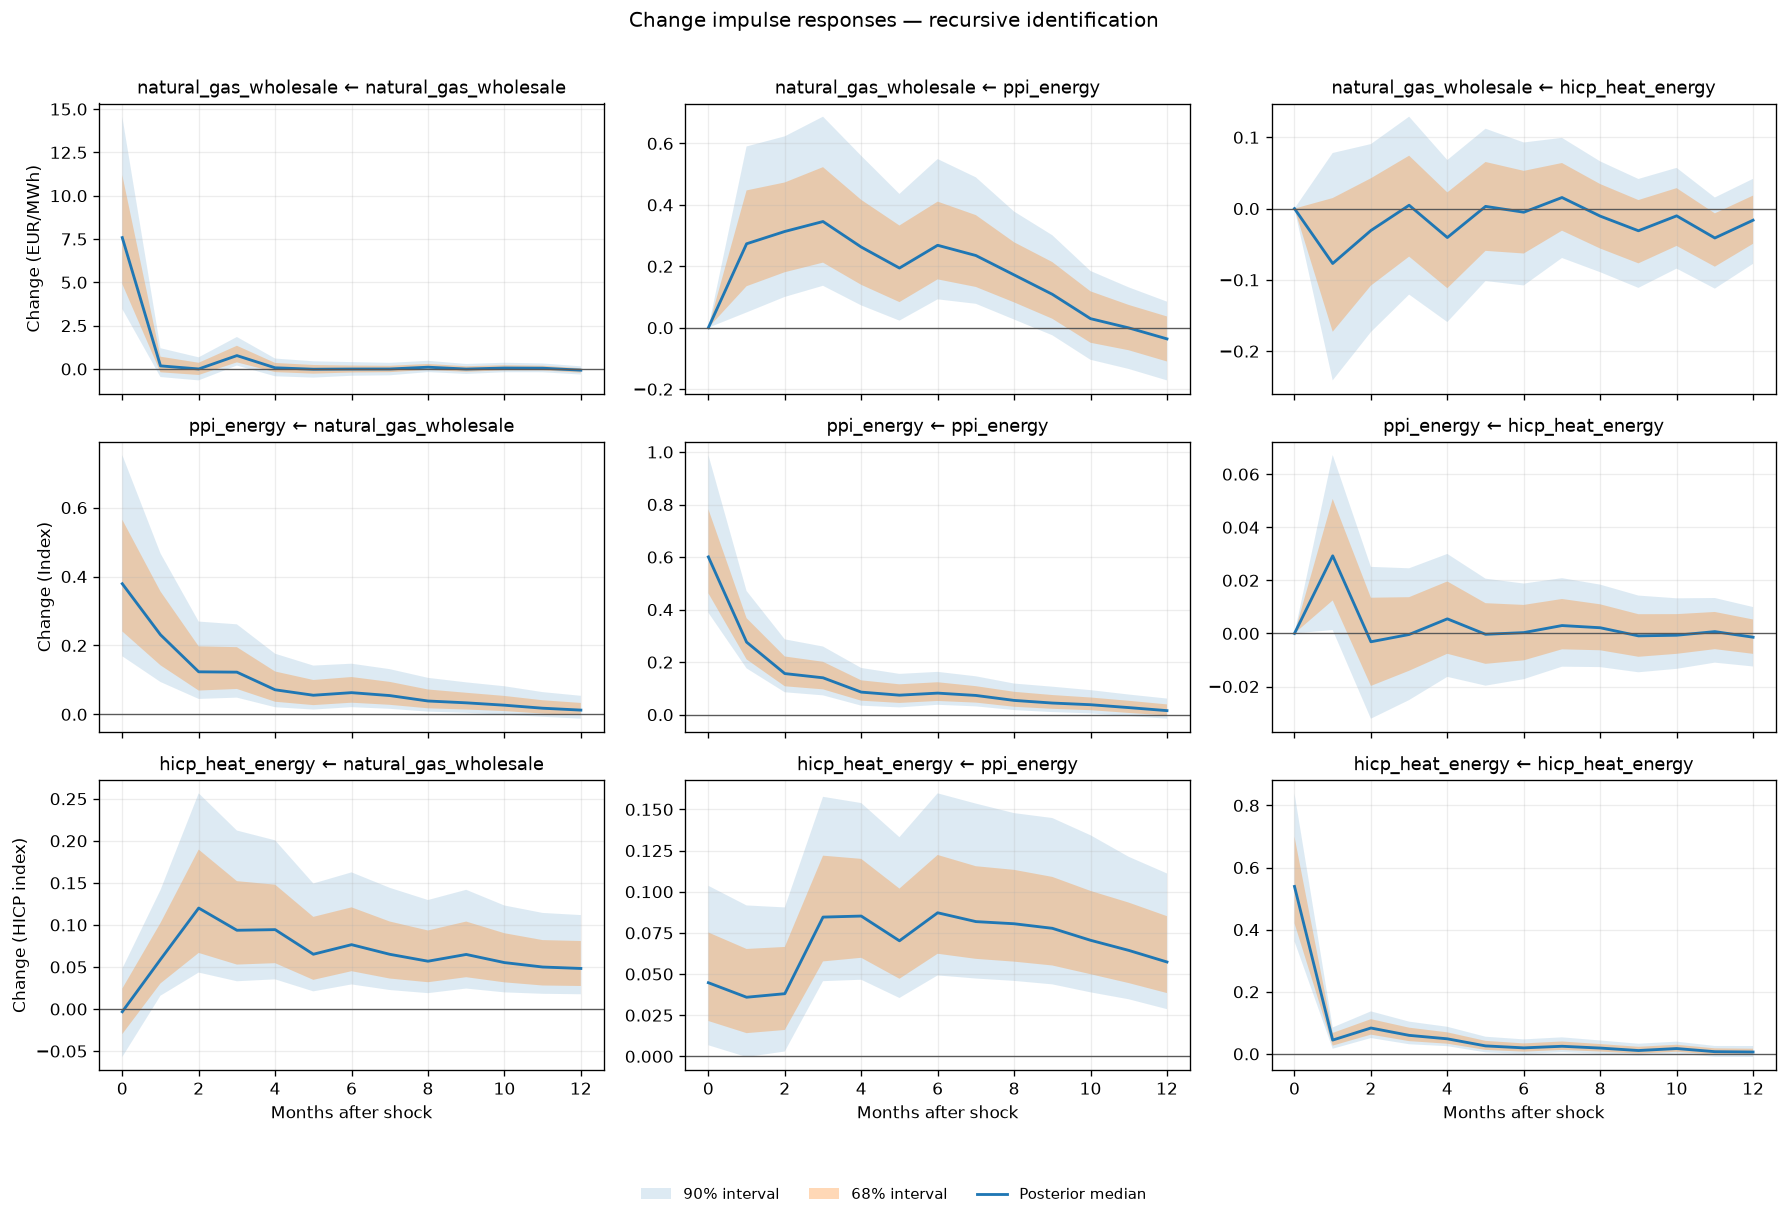

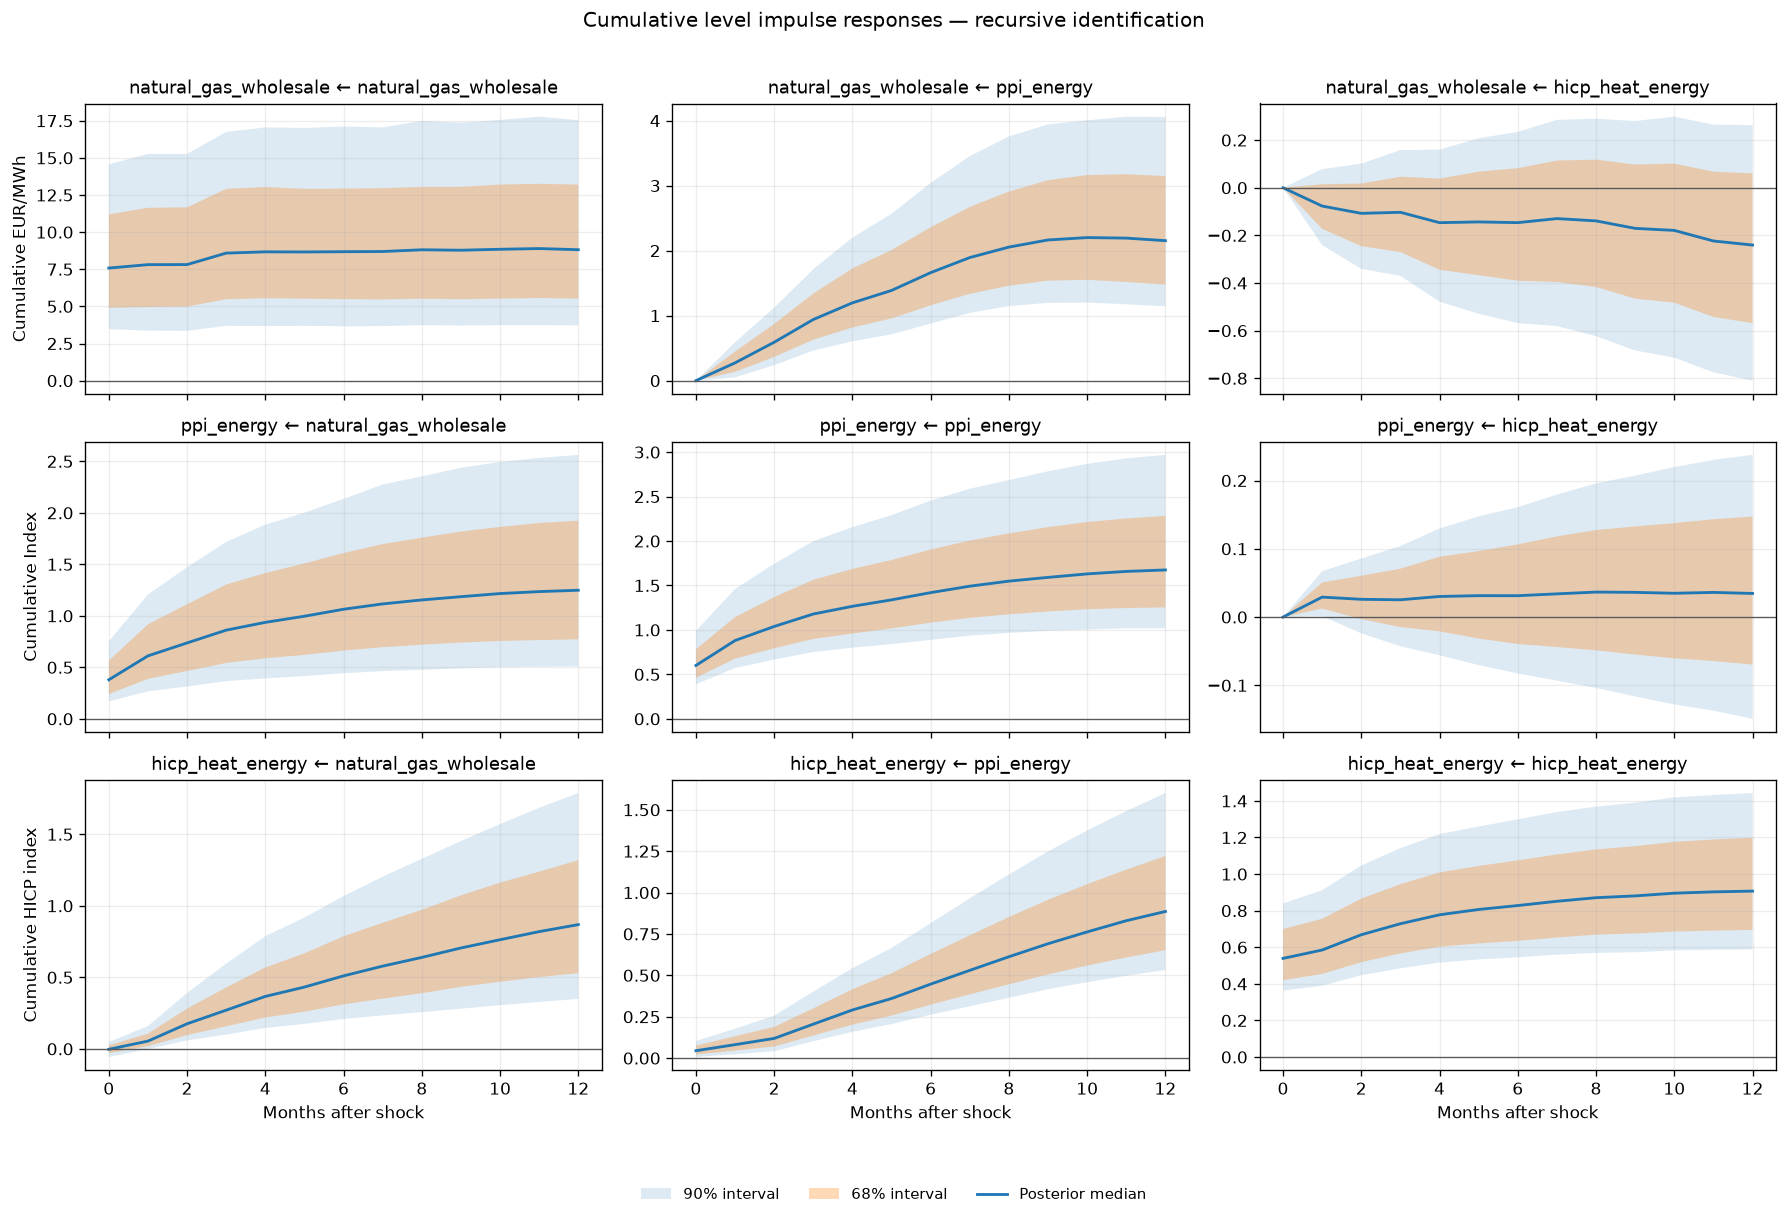

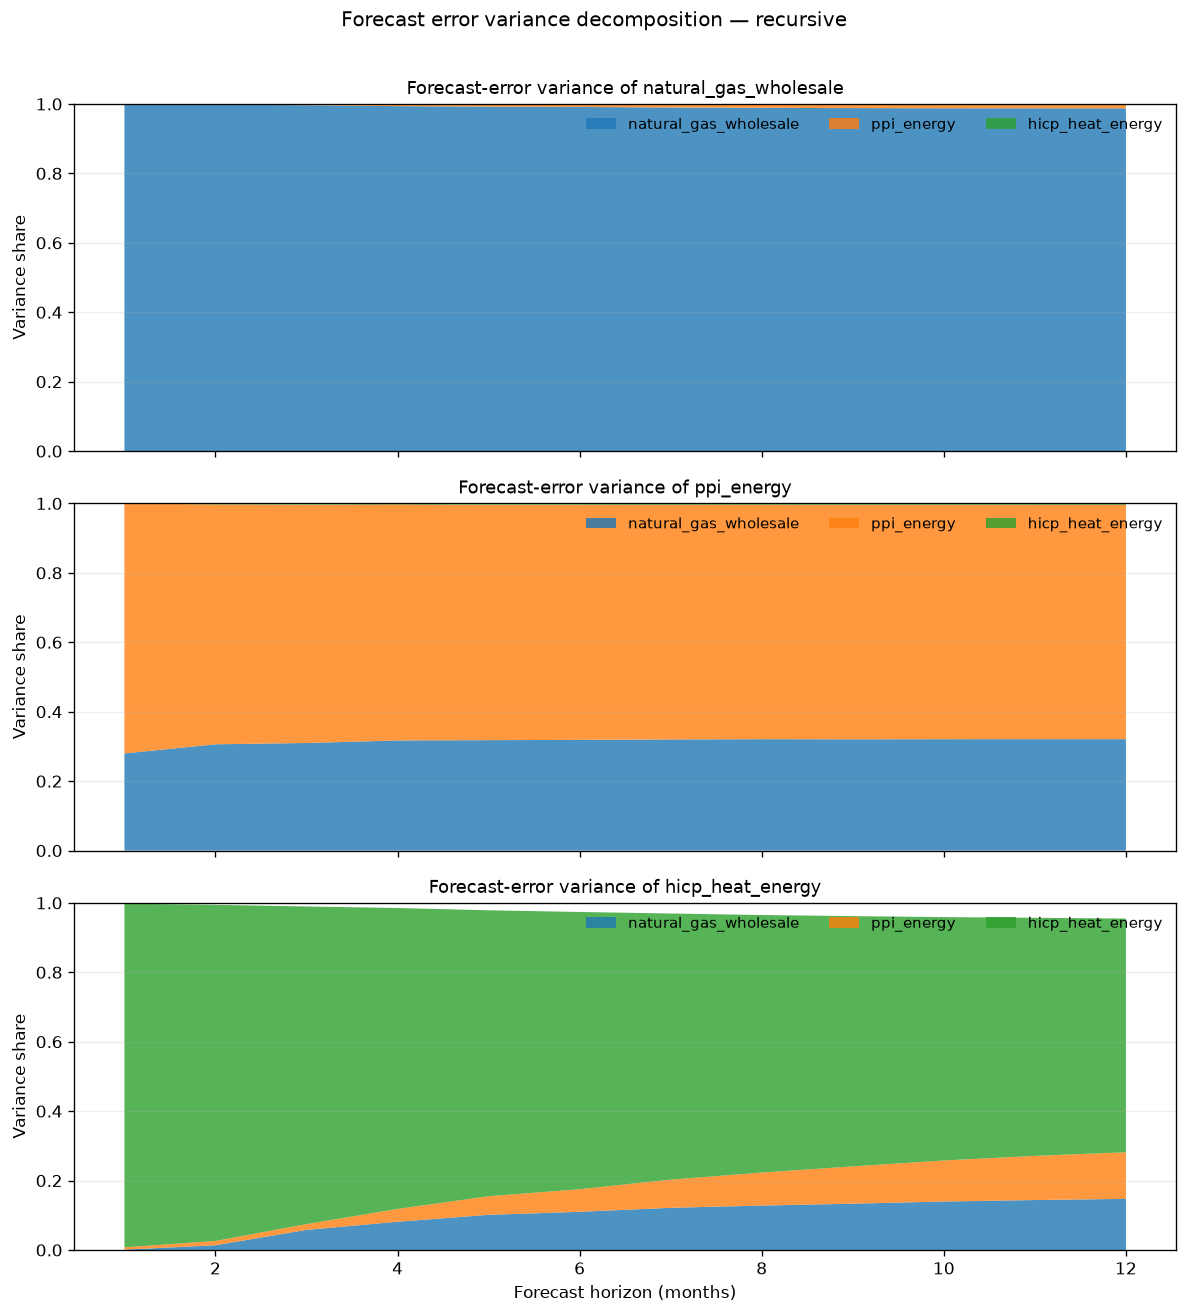

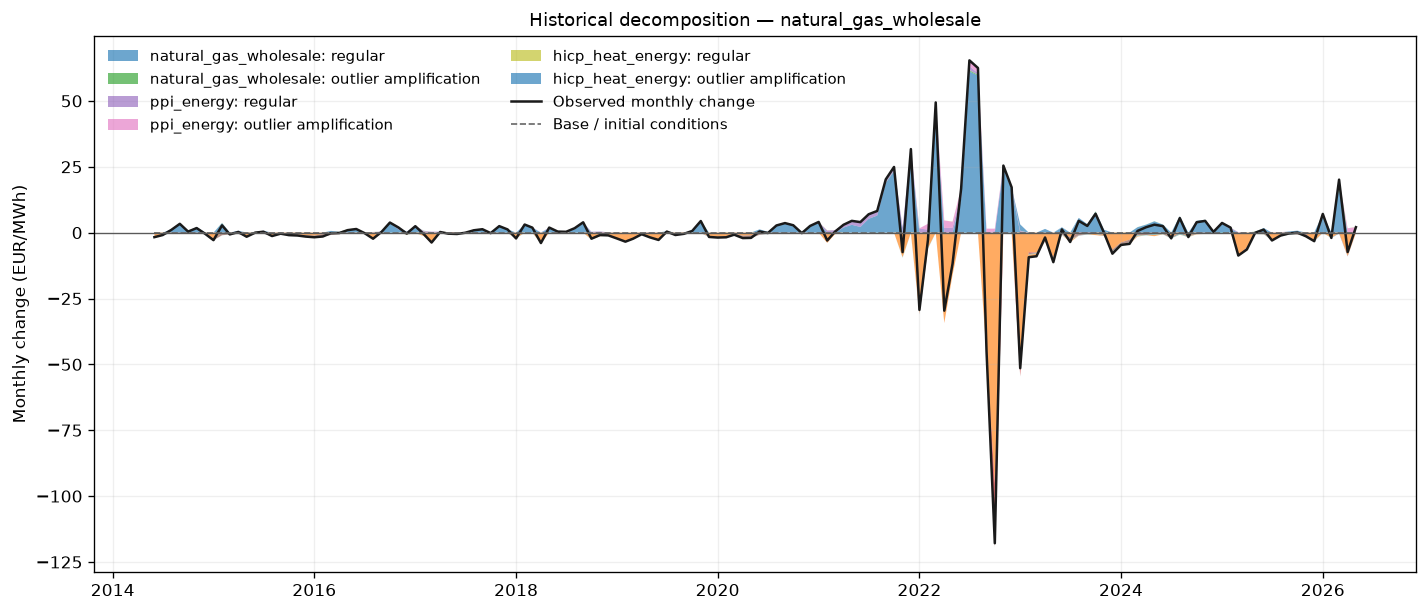

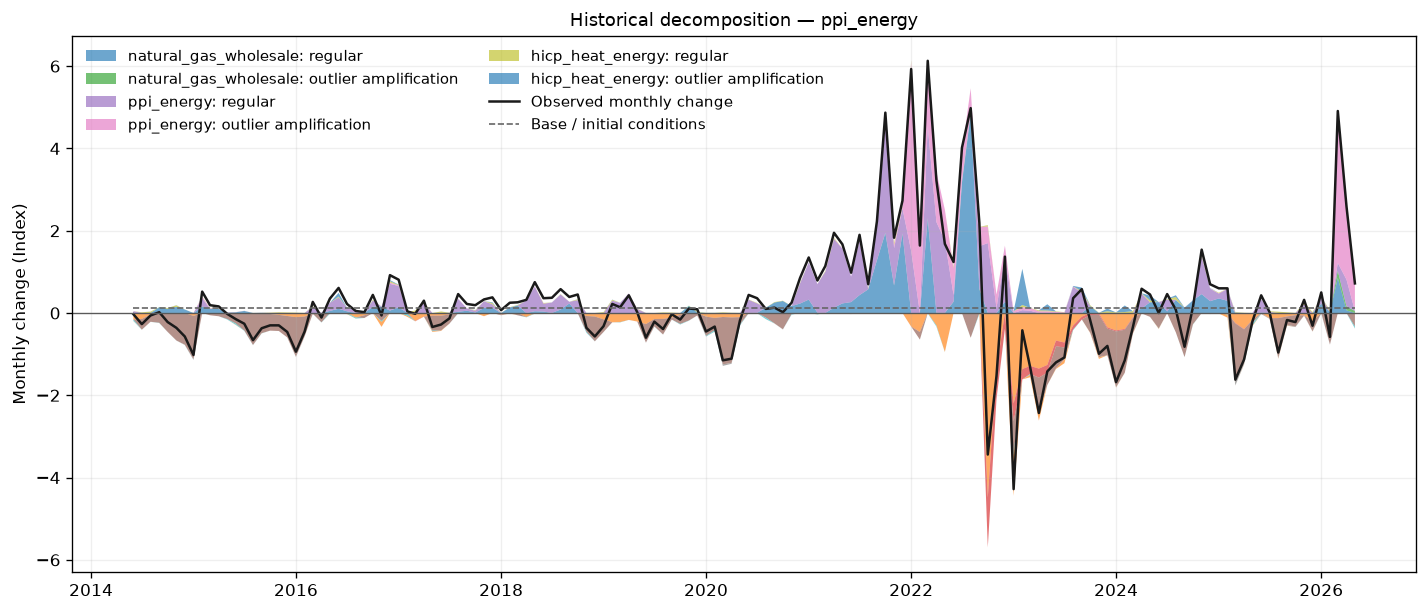

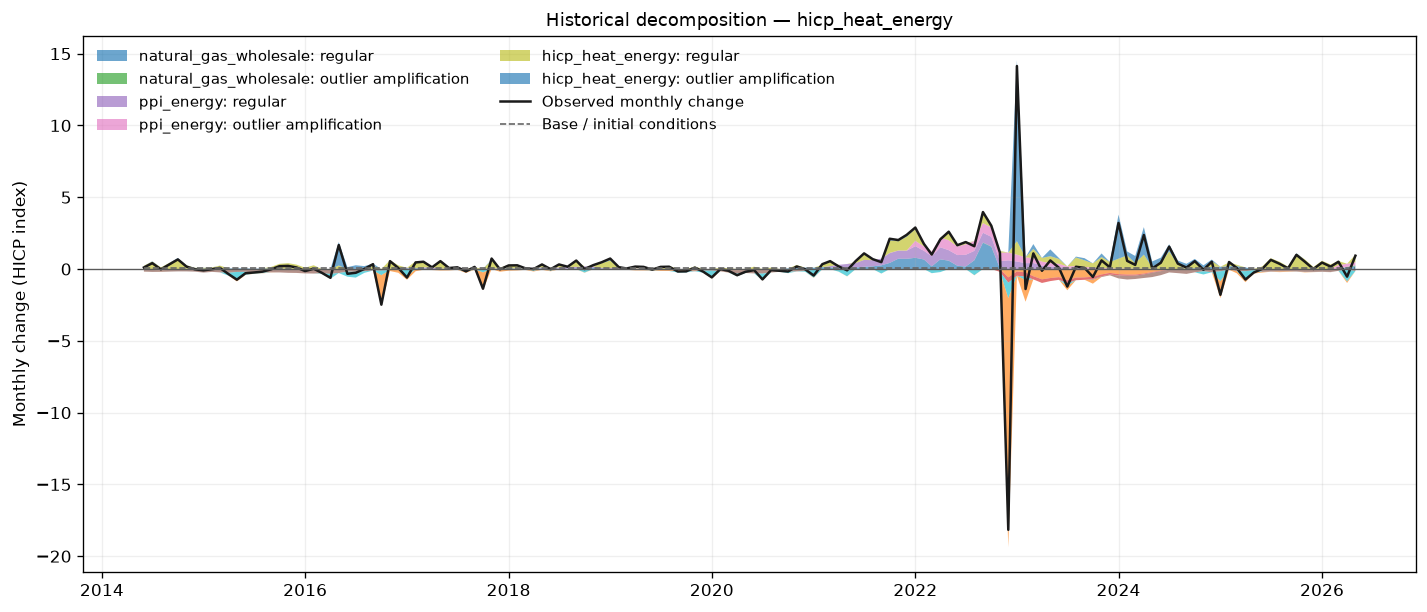


Sign-restricted identification
Accepted posterior-draw share: 100.00%
Mean attempts per accepted draw: 5.38
HD maximum reconstruction error: 2.84 × 10⁻¹³


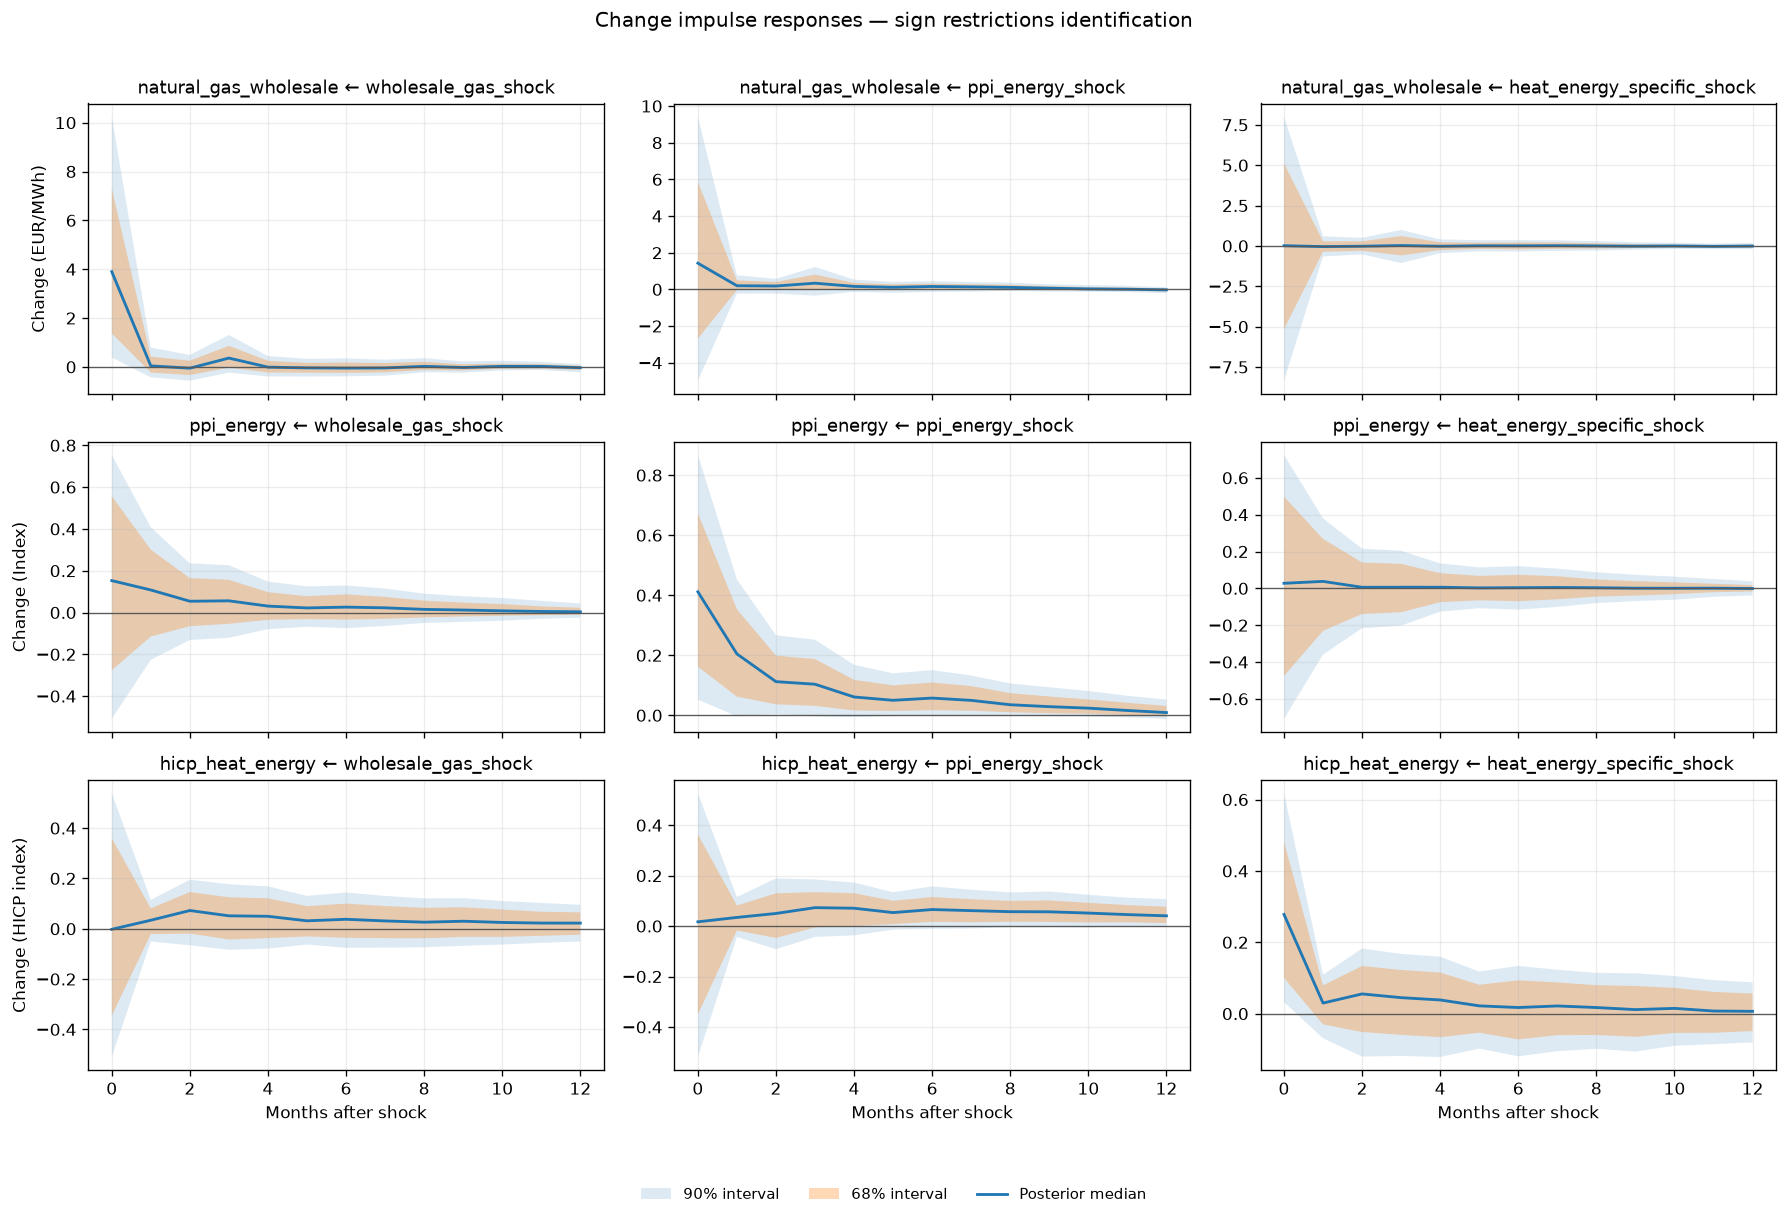

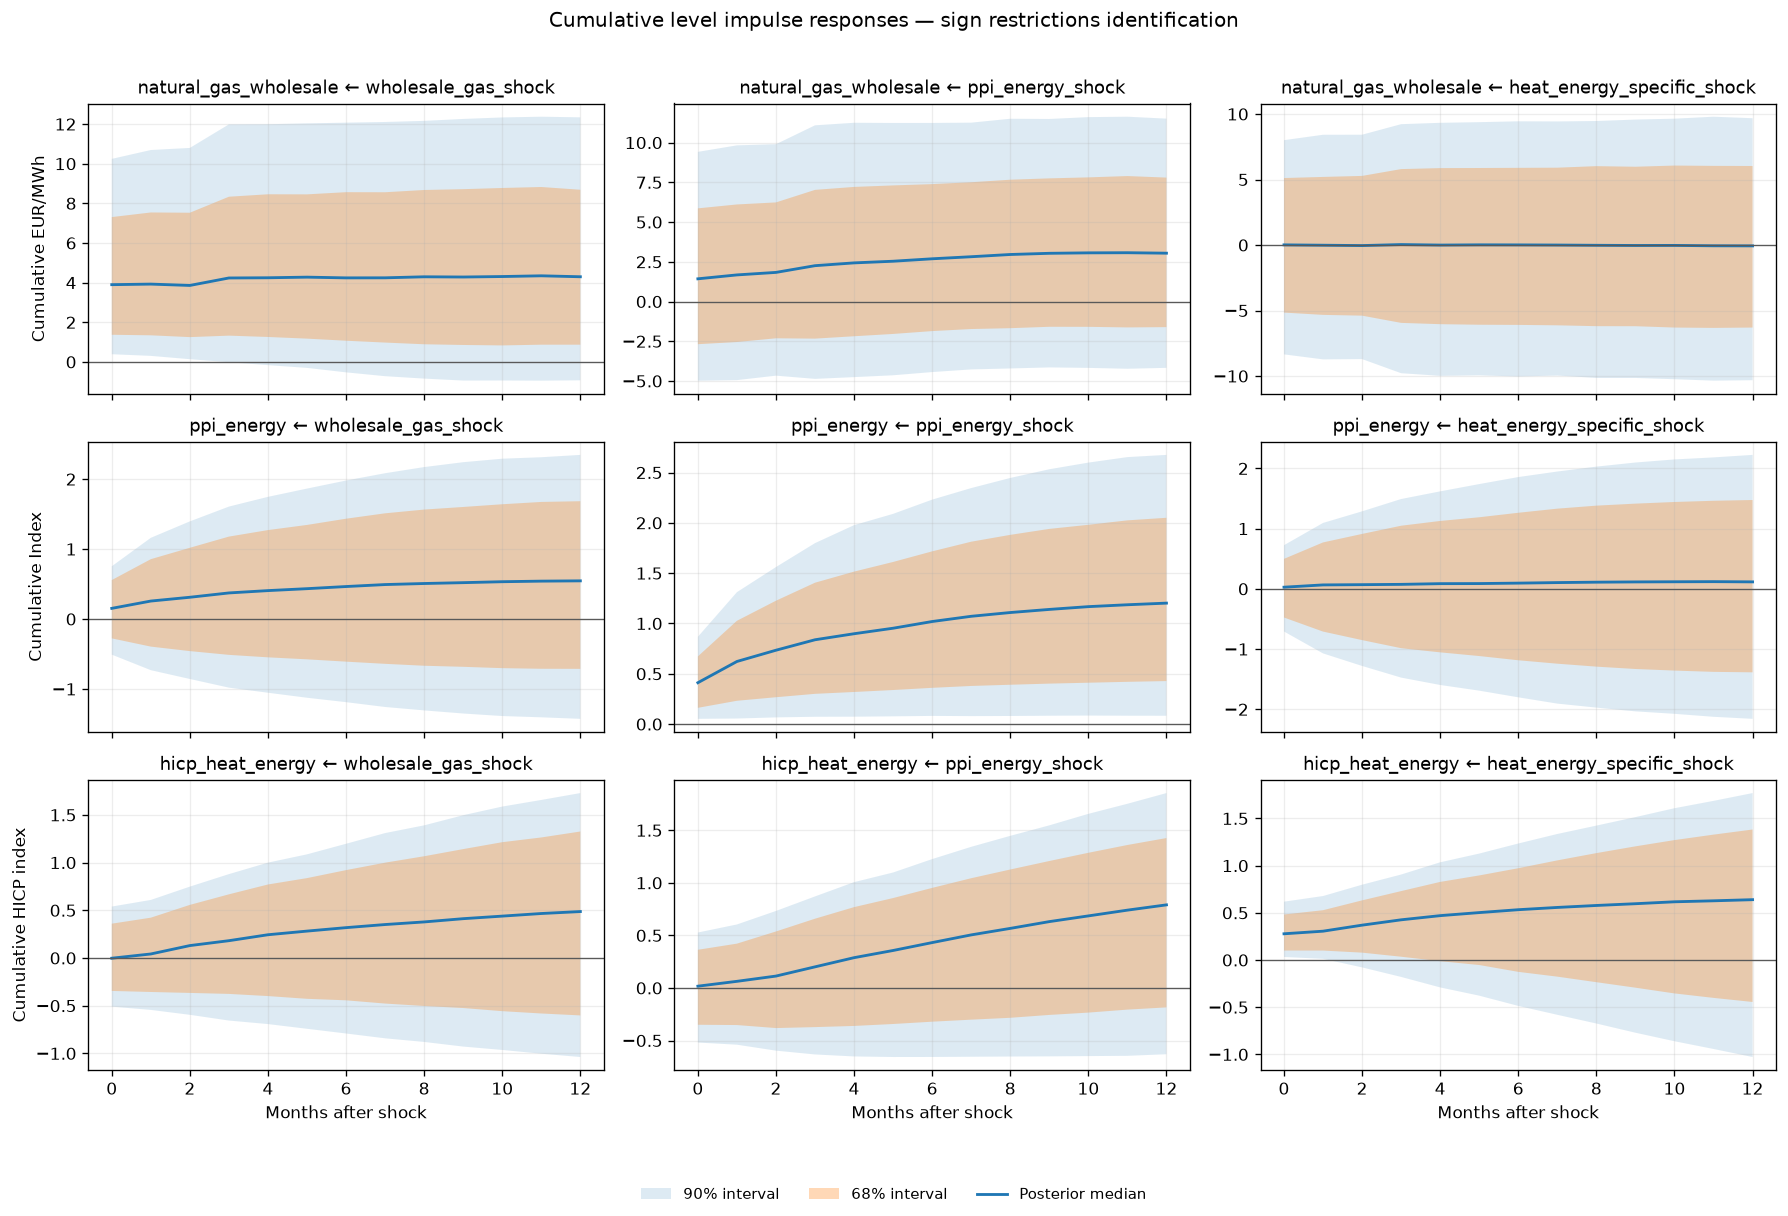

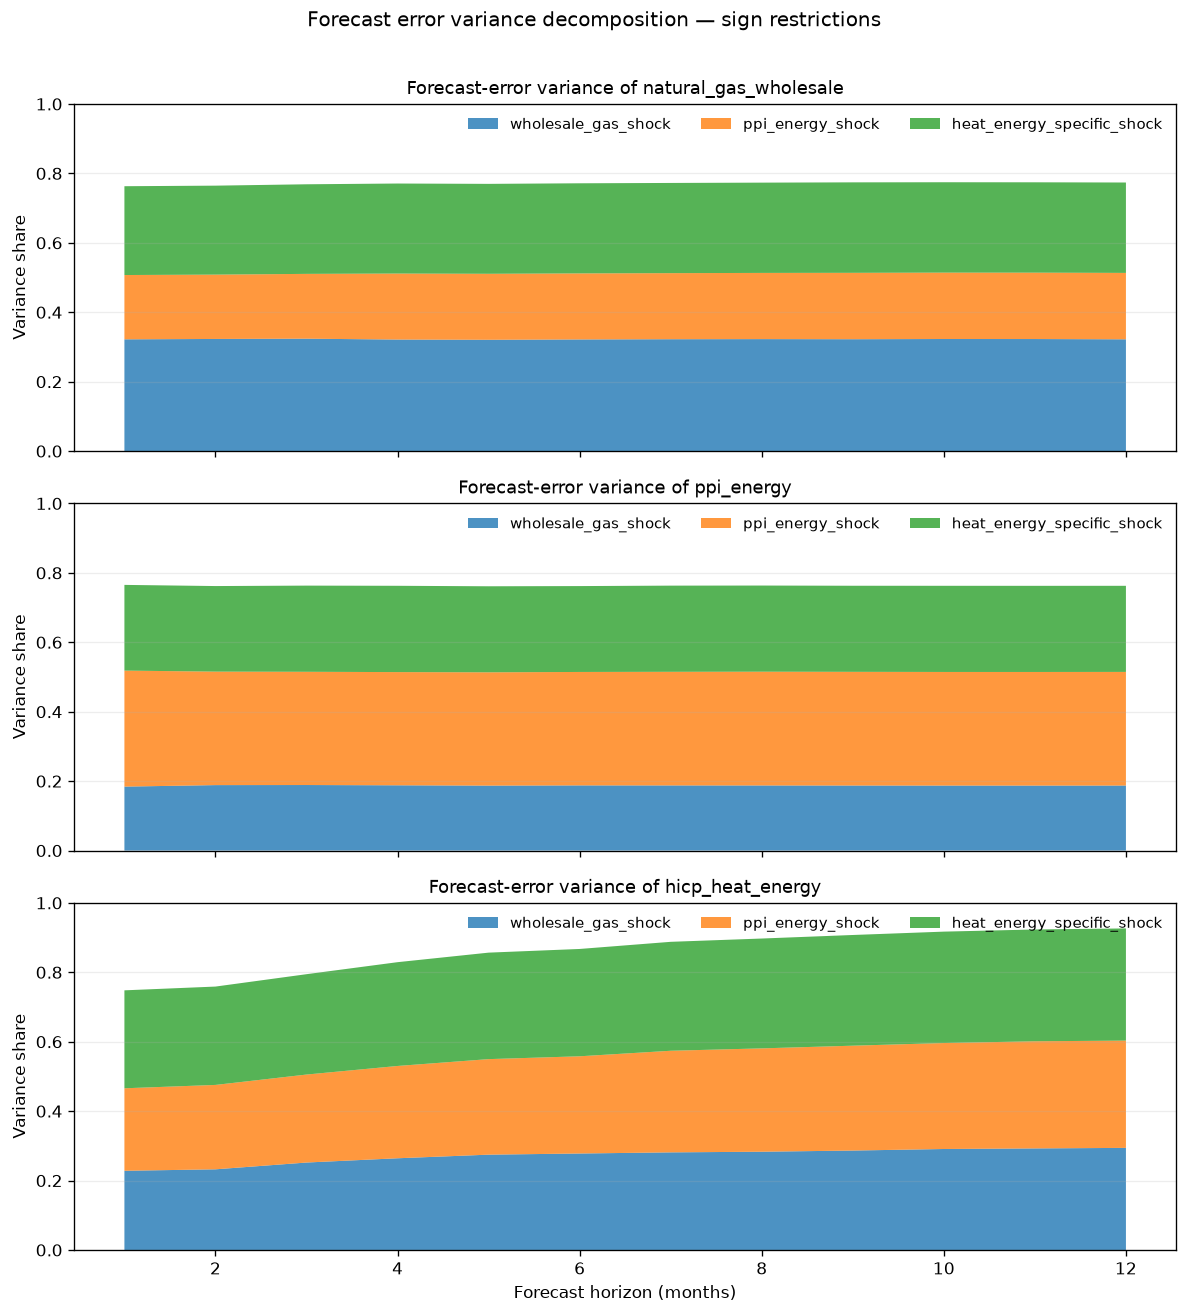

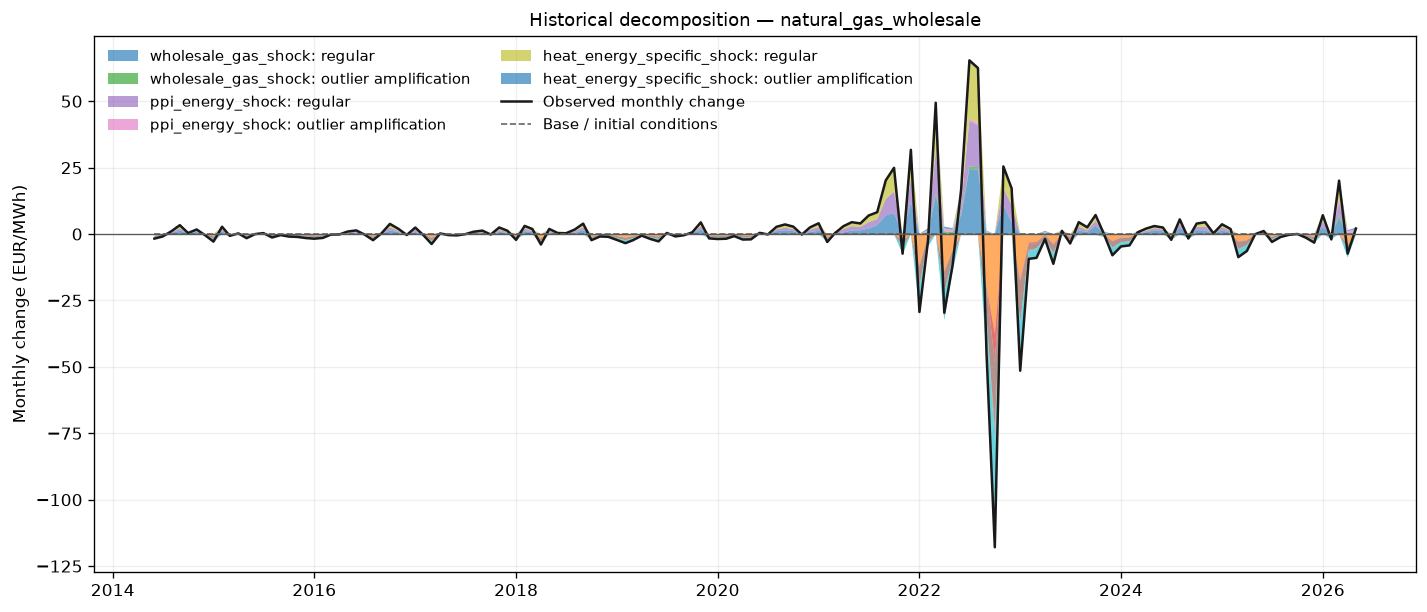

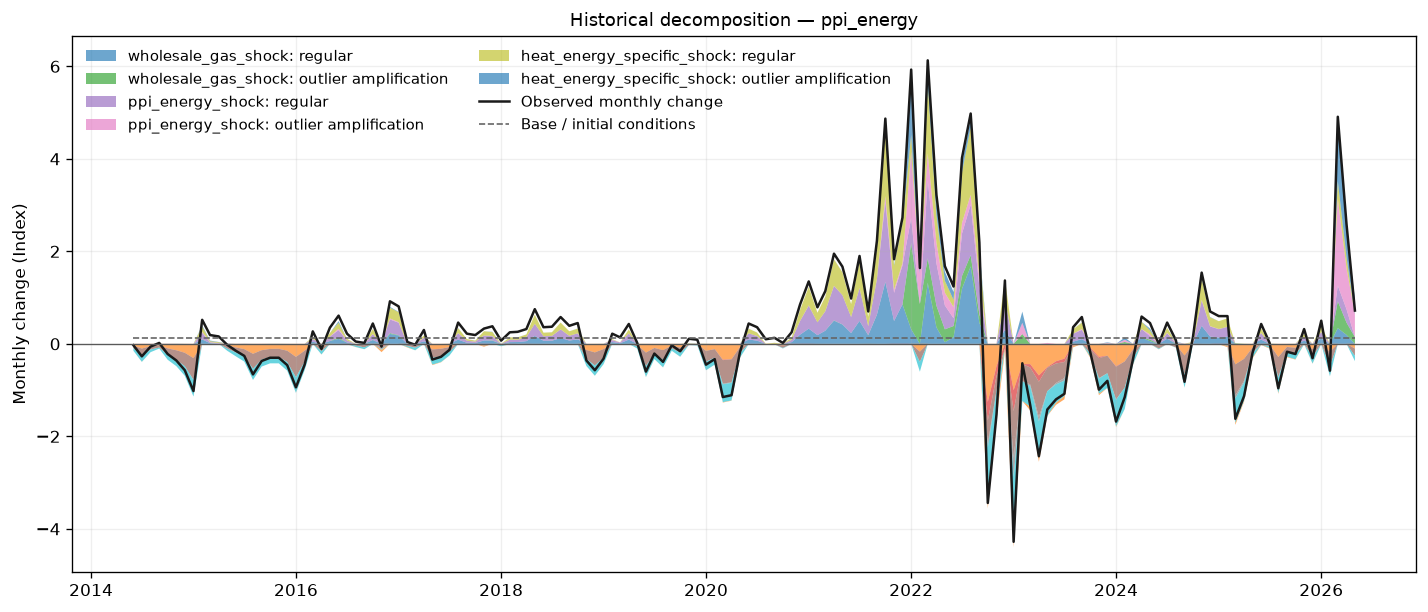

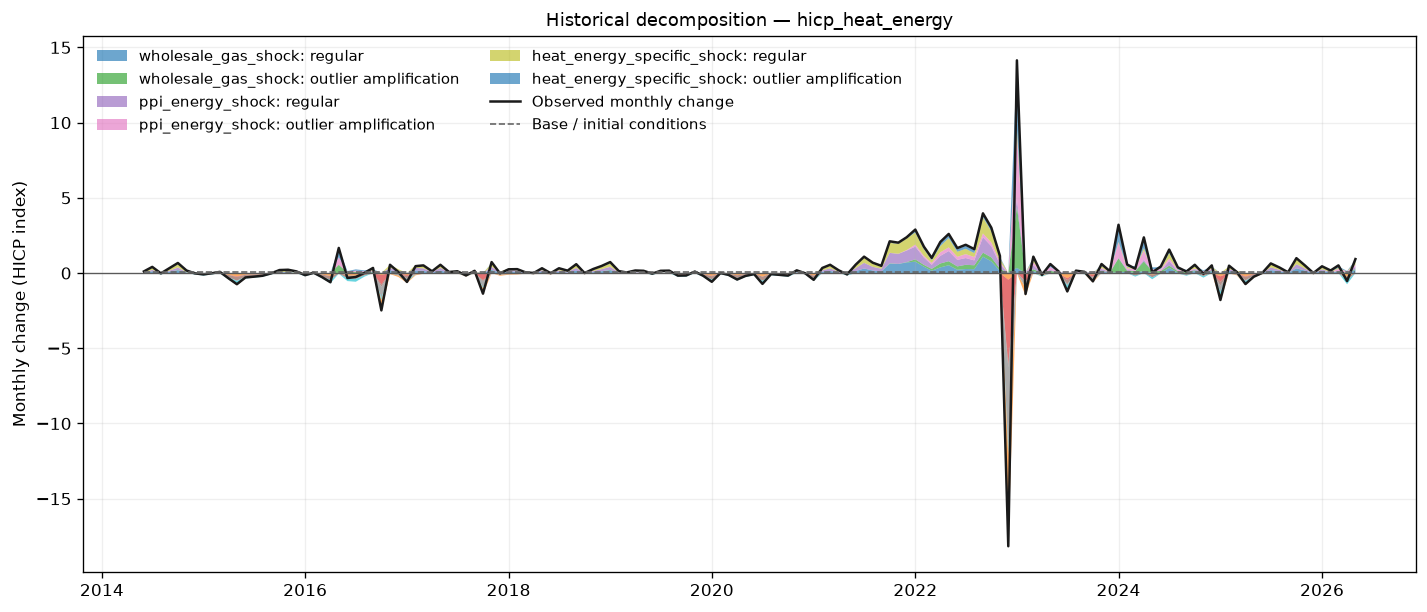

In [15]:
COMPONENT_SIGN_RESTRICTIONS = {
    "wholesale_gas_shock": {
        "natural_gas_wholesale": {0: +1},
    },
    "ppi_energy_shock": {
        "ppi_energy": {0: +1},
    },
    "heat_energy_specific_shock": {
        TARGET: {0: +1},
    },
}

STRUCTURAL_REFERENCE_DATE = prep["balanced_end"]
STRUCTURAL_HORIZON = 12

irf_recursive = impulse_responses(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
)
fevd_recursive = forecast_error_variance_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
)
hd_recursive = historical_decomposition(
    result,
    identification="recursive",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    split_outlier_amplification=True,
)

print("Recursive identification")
print(f"Reference date: {pd.Timestamp(STRUCTURAL_REFERENCE_DATE).date()}")
print(f"HD maximum reconstruction error: {format_number(hd_recursive['max_reconstruction_error'])}")
plot_impulse_responses(irf_recursive, cumulative=False, units=UNITS)
plot_impulse_responses(irf_recursive, cumulative=True, units=UNITS)
plot_fevd(fevd_recursive)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_recursive,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

irf_sign = impulse_responses(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=COMPONENT_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    shock_unit="structural_std",
    include_outlier_scale=False,
    max_tries=20_000,
    seed=SEED,
)
fevd_sign = forecast_error_variance_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=COMPONENT_SIGN_RESTRICTIONS,
    horizon=STRUCTURAL_HORIZON,
    include_outlier_scale=False,
    max_tries=20_000,
    seed=SEED,
)
hd_sign = historical_decomposition(
    result,
    identification="sign",
    reference_date=STRUCTURAL_REFERENCE_DATE,
    sign_restrictions=COMPONENT_SIGN_RESTRICTIONS,
    split_outlier_amplification=True,
    max_tries=20_000,
    seed=SEED,
)

print()
print("Sign-restricted identification")
print(f"Accepted posterior-draw share: {irf_sign['acceptance_rate']:.2%}")
print(f"Mean attempts per accepted draw: {irf_sign['mean_attempts_per_accepted_draw']:.2f}")
print(f"HD maximum reconstruction error: {format_number(hd_sign['max_reconstruction_error'])}")
plot_impulse_responses(irf_sign, cumulative=False, units=UNITS)
plot_impulse_responses(irf_sign, cumulative=True, units=UNITS)
plot_fevd(fevd_sign)
for response in VARIABLES:
    plot_historical_decomposition(
        hd_sign,
        response=response,
        last_obs=144,
        unit=UNITS[response],
    )
plt.show()

## 9. Diagnosis

### 9.1 Stationarity of transformed endogenous data

In [16]:
stationarity_table = stationarity_tests(prep["balanced"])
display(style_numeric_table(
    stationarity_table,
    caption="Stationarity diagnostics",
))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
natural_gas_wholesale,-5.10,1.38 × 10⁻⁵,15.00,0.04,0.10,26.00,300.00
ppi_energy,-4.00,1.43 × 10⁻³,13.00,0.12,0.10,9.00,302.00
hicp_heat_energy,-6.35,2.69 × 10⁻⁸,4.00,0.31,0.10,4.00,311.00


### 9.2 MCMC effective sample size and autocorrelation

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
phi[hicp_heat_energy],0.02,0.01,37.84,1.89 × 10⁻³,0.16
phi[ppi_energy],0.03,0.01,60.35,1.91 × 10⁻³,0.13
phi[natural_gas_wholesale],0.18,0.05,97.23,5.30 × 10⁻³,0.10
log likelihood,-759.65,14.07,299.35,0.81,0.06
"A[ppi_energy,natural_gas_wholesale]",-0.05,6.07 × 10⁻³,397.87,3.04 × 10⁻⁴,0.05
p_outlier[natural_gas_wholesale],0.01,7.25 × 10⁻³,414.93,3.56 × 10⁻⁴,0.05
own L1[natural_gas_wholesale],2.27 × 10⁻³,0.06,610.91,2.39 × 10⁻³,0.04
p_outlier[ppi_energy],0.02,7.68 × 10⁻³,680.72,2.94 × 10⁻⁴,0.04
p_outlier[hicp_heat_energy],0.06,0.01,784.83,5.24 × 10⁻⁴,0.04
own L1[hicp_heat_energy],0.08,0.03,917.89,1.02 × 10⁻³,0.03


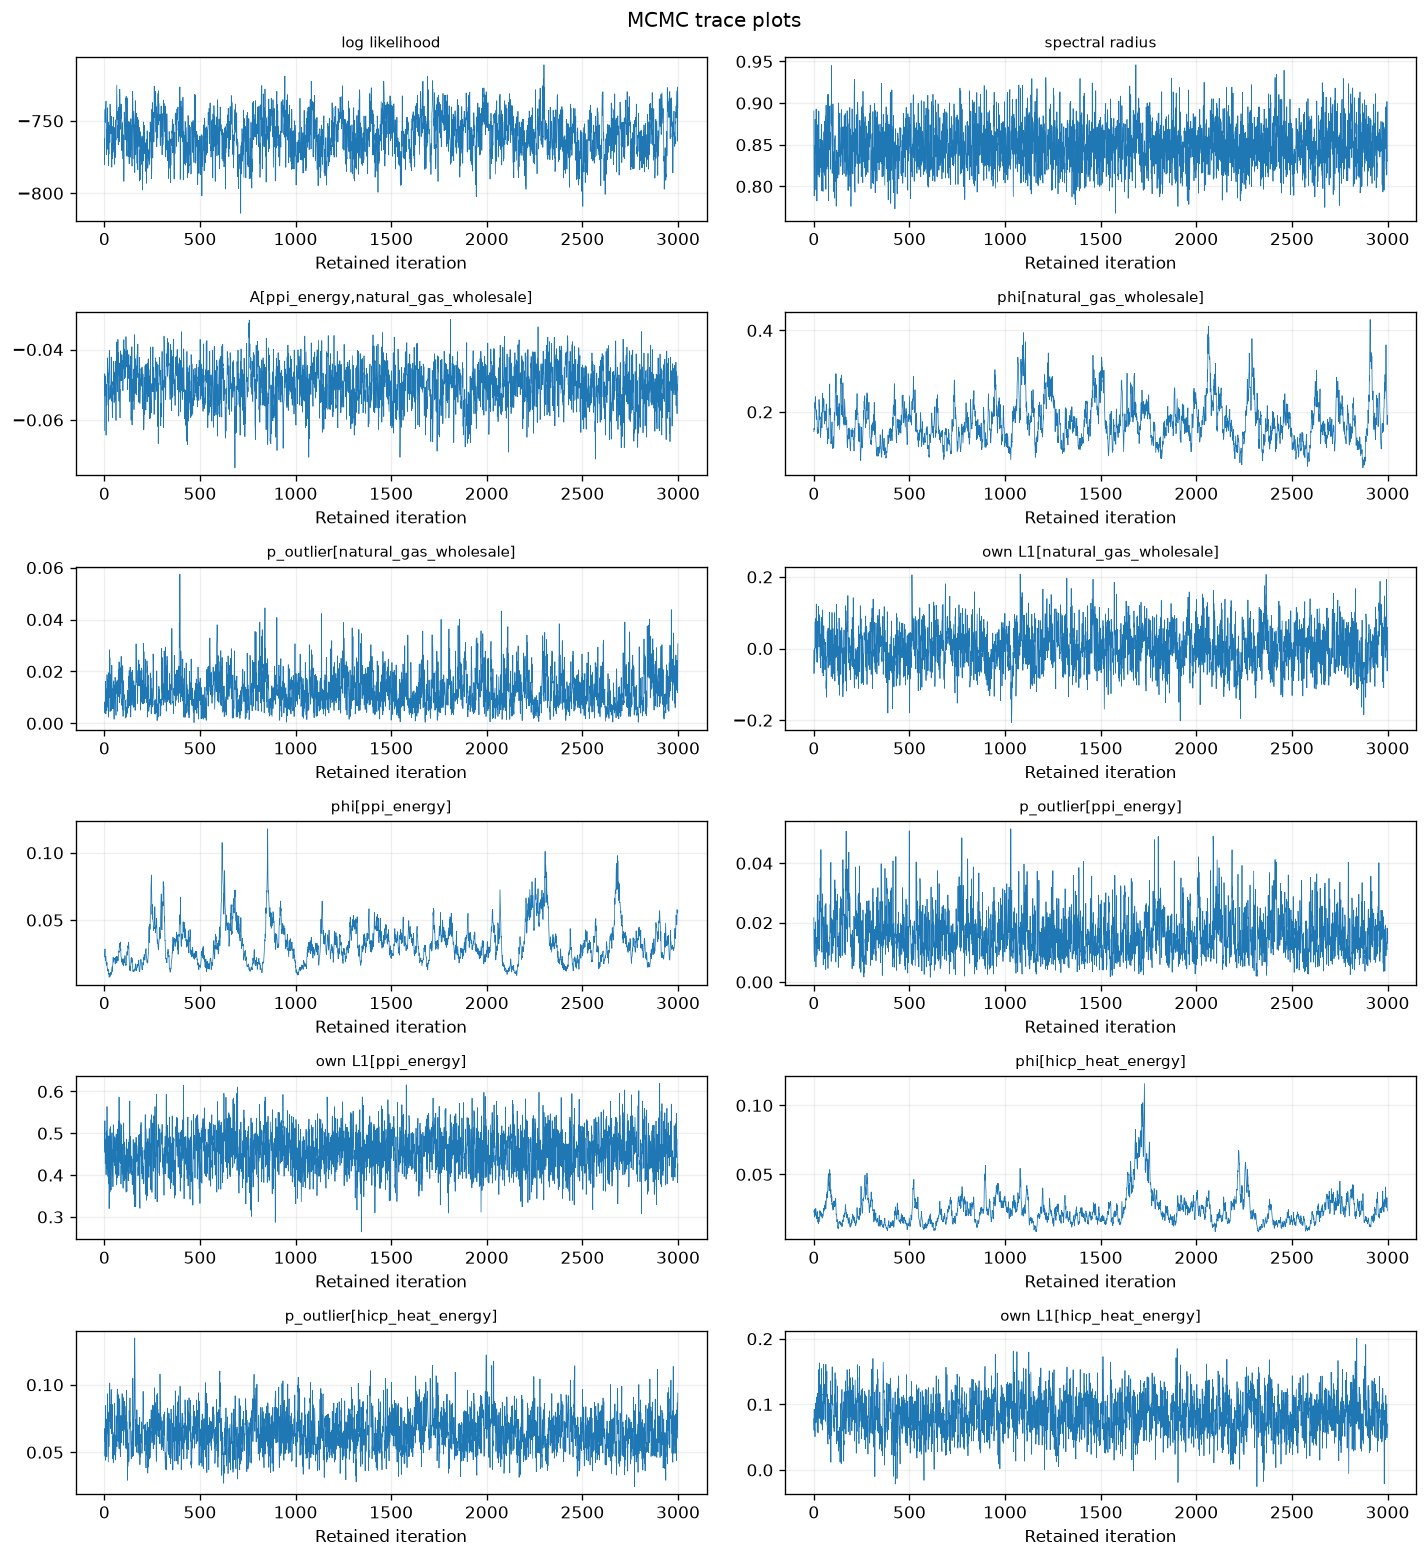

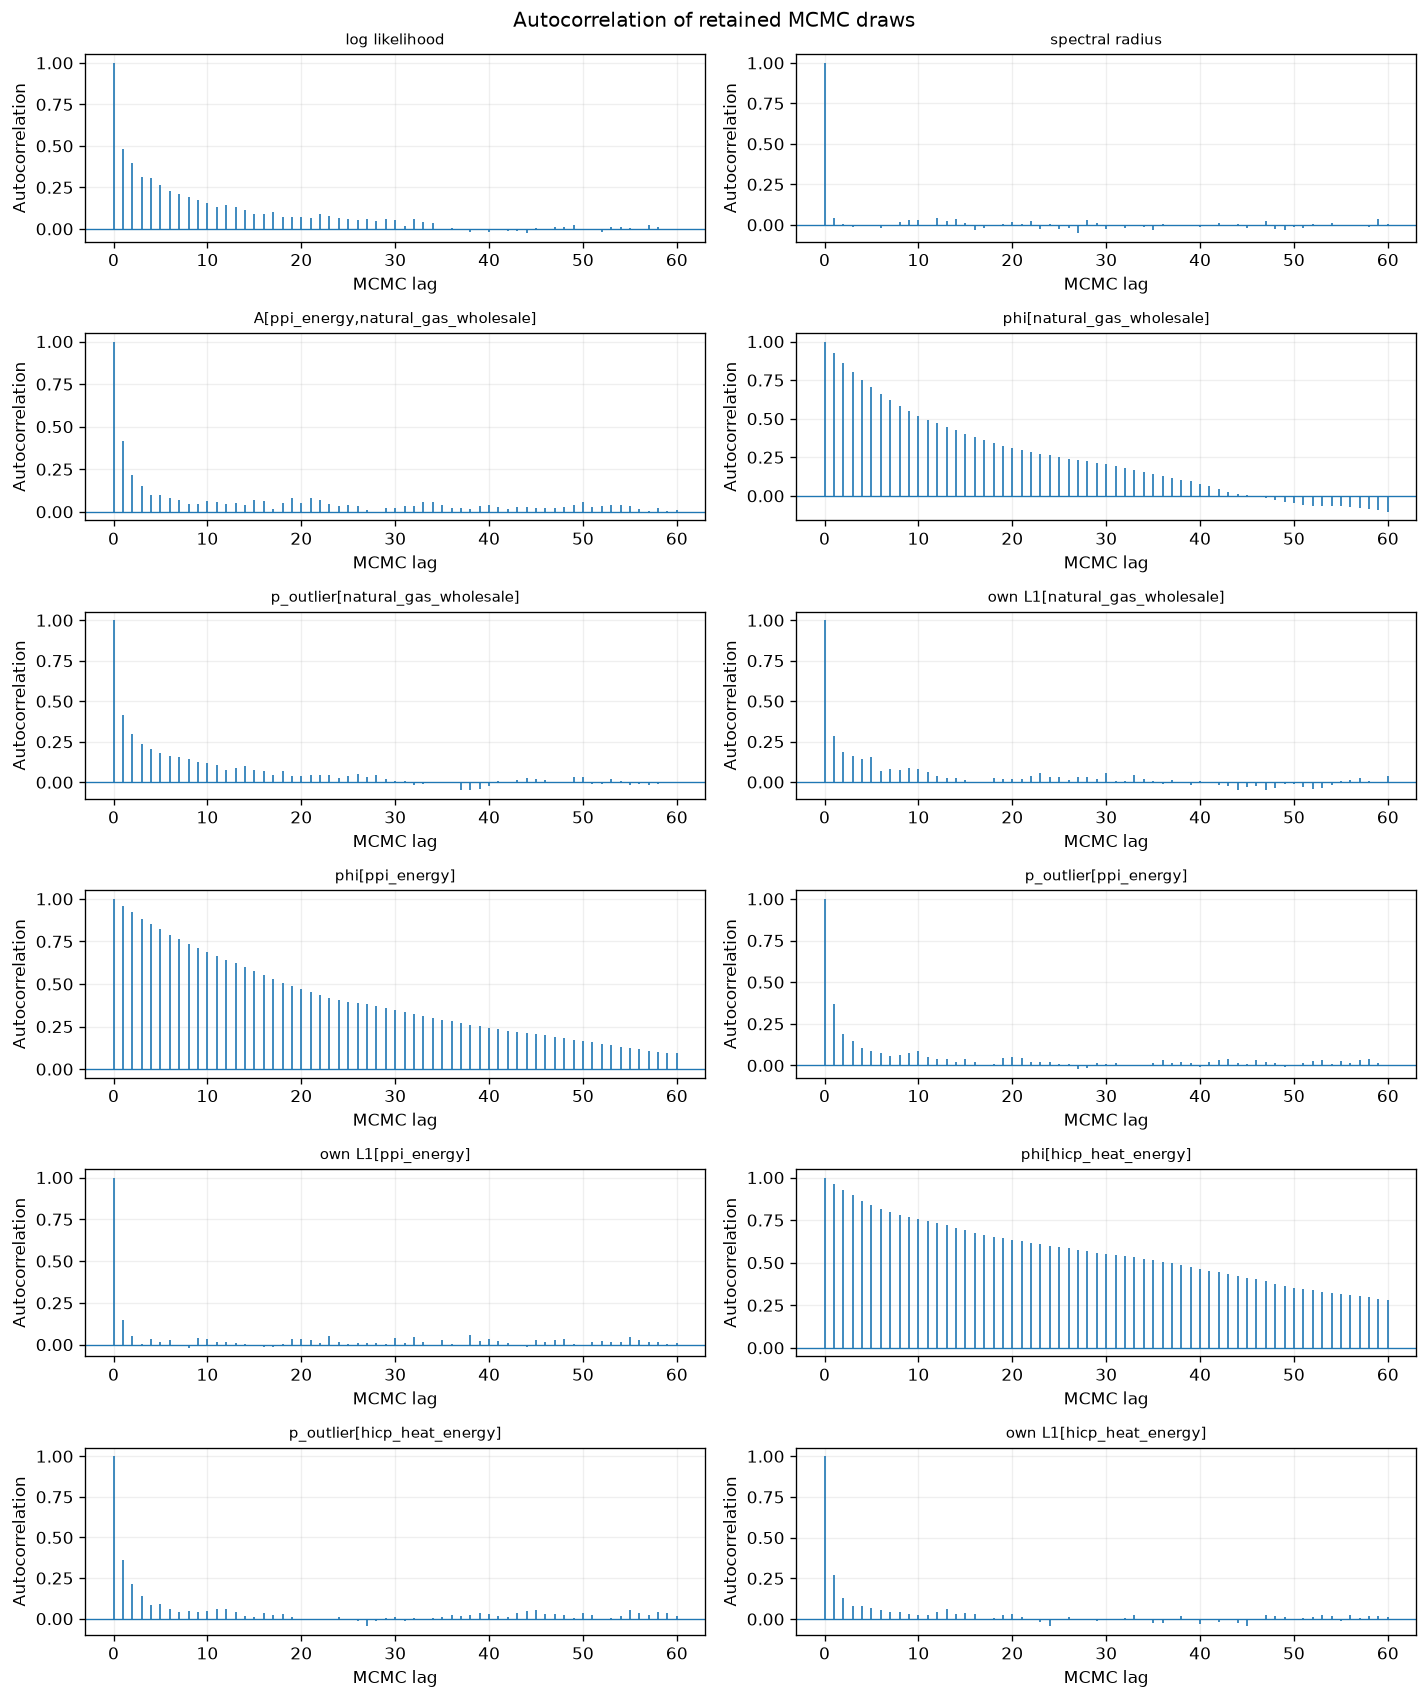

In [17]:
diagnostic_table = mcmc_diagnostics(result)
display(style_numeric_table(
    diagnostic_table.sort_values("ESS"),
    caption="MCMC diagnostics",
))
plot_trace_grid(result)
plot_chain_acf_grid(result, nlags=60)
plt.show()

### 9.3 Stability

,value
retained_draws,3000.00
median_spectral_radius,0.85
q95_spectral_radius,0.90
maximum_spectral_radius,0.95
retained_unstable_share,0.00
B_total_proposals,6000.00
B_unstable_proposals,0.00
B_instability_rejection_rate,0.00


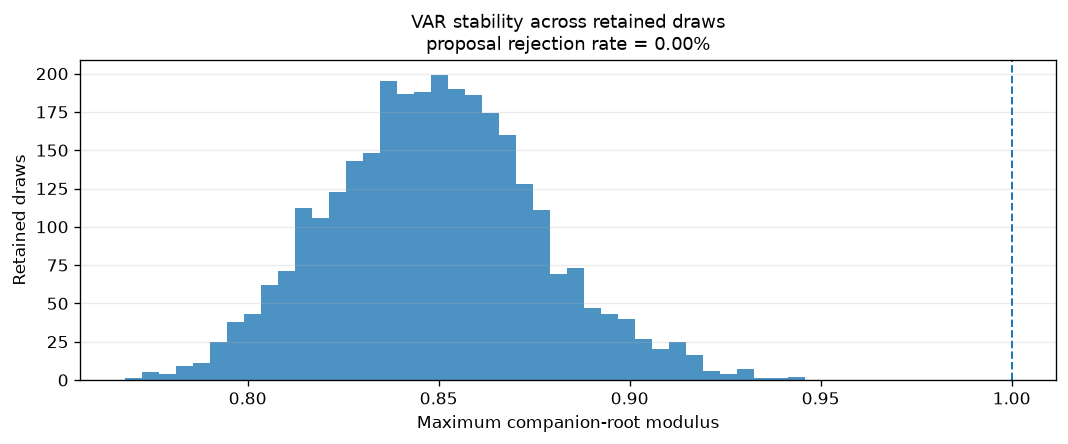

In [18]:
display(style_numeric_table(
    stability_diagnostics(result).to_frame("value"),
    caption="VAR stability diagnostics",
))
plot_spectral_radius(result)
plt.show()

### 9.4 Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
natural_gas_wholesale: mean,0.10,0.06,-1.45,1.27
natural_gas_wholesale: sd,10.97,9.51,6.59,21.04
natural_gas_wholesale: maximum_absolute,117.89,86.64,49.67,316.34


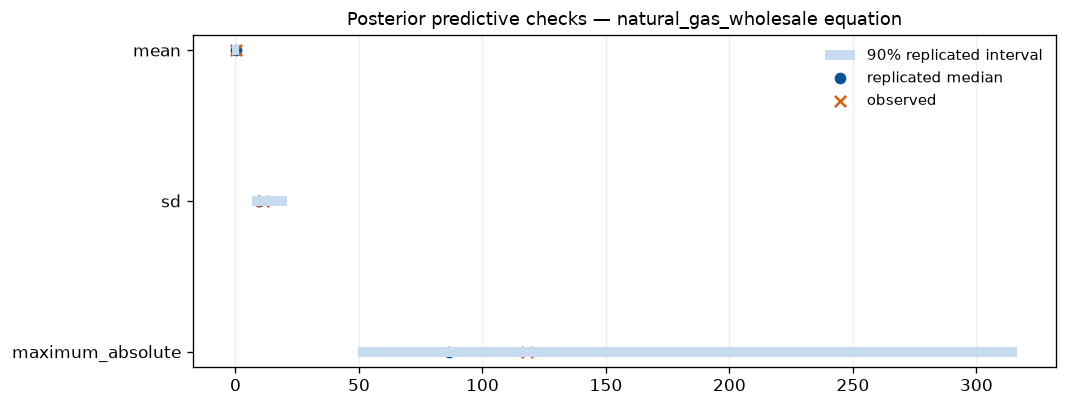

,observed,replicated_median,replicated_q05,replicated_q95
ppi_energy: mean,0.21,0.12,-0.23,0.46
ppi_energy: sd,1.02,1.19,0.73,2.39
ppi_energy: maximum_absolute,6.13,10.47,4.63,30.04


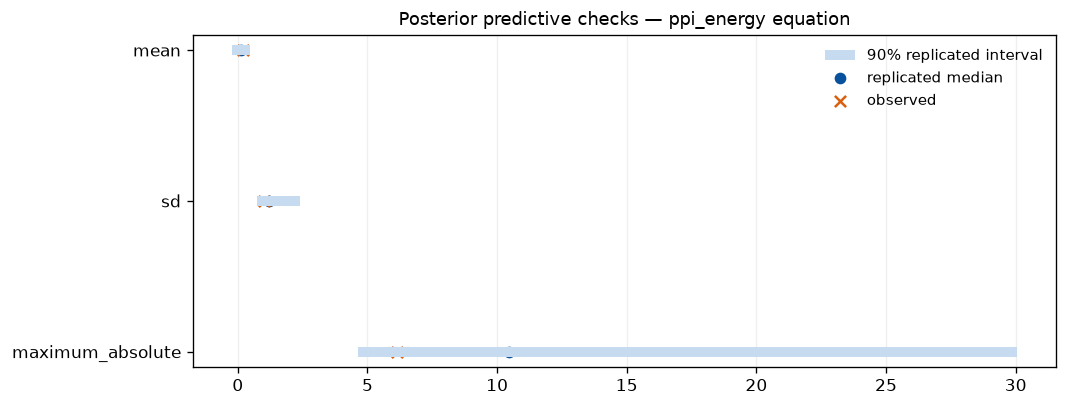

,observed,replicated_median,replicated_q05,replicated_q95
hicp_heat_energy: mean,0.22,0.09,-0.29,0.38
hicp_heat_energy: sd,1.51,1.30,0.91,2.39
hicp_heat_energy: maximum_absolute,18.16,12.58,6.51,29.23


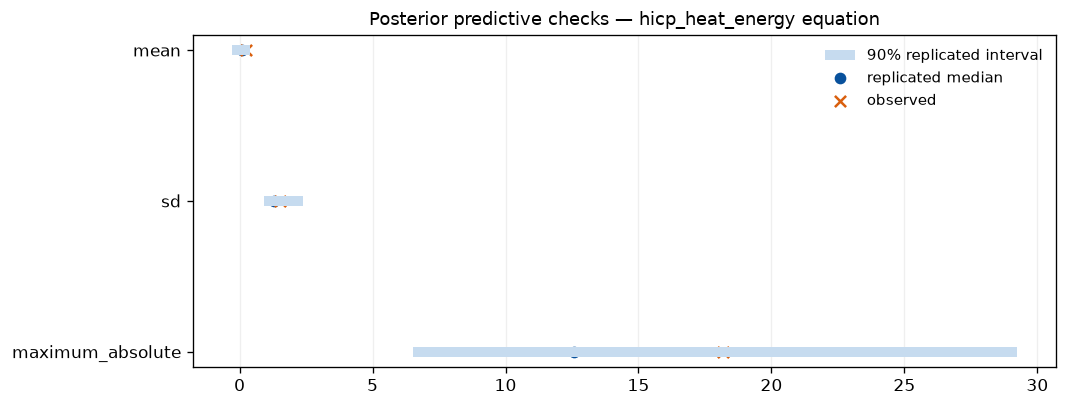

In [19]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=2027,
)
for equation in VARIABLES:
    equation_rows = ppc_summary.loc[
        [str(index).startswith(f"{equation}:") for index in ppc_summary.index]
    ]
    display(style_numeric_table(
        equation_rows,
        caption=f"Posterior predictive checks — {equation}",
    ))
    plot_posterior_predictive_check(ppc_summary, equation=equation)
    plt.show()

# check to supp

In [20]:
print("diff_paths :", forecast_unconditional["diff_paths"].shape)
print("level_paths:", forecast_unconditional["level_paths"].shape)
print("tail_length:", forecast_unconditional["tail_length"])
print("tail dates  :", forecast_unconditional["tail_dates"])
print("future dates:", forecast_unconditional["future_dates"])

diff_paths : (1000, 7, 3)
level_paths: (1000, 7, 3)
tail_length: 3
tail dates  : DatetimeIndex(['2026-06-01', '2026-07-01', '2026-08-01'], dtype='datetime64[us]', name='date', freq='MS')
future dates: DatetimeIndex(['2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'], dtype='datetime64[us]', freq='MS')


In [21]:
import numpy as np

base_level = np.asarray(
    result["prep"]["level_at_balanced_end"],
    dtype=float,
)

levels_reconstructed = (
    base_level[None, None, :]
    + np.cumsum(
        forecast_unconditional["diff_paths"],
        axis=1,
    )
)

max_cumulative_error = np.max(
    np.abs(
        levels_reconstructed
        - forecast_unconditional["level_paths"]
    )
)

print("Erreur cumulative maximale :", max_cumulative_error)

Erreur cumulative maximale : 69639.78384346787


In [22]:
observed = (
    result["prep"]["levels"]
    .reindex(forecast_unconditional["path_dates"])
    [result["variables"]]
    .to_numpy(dtype=float)
)

paths = forecast_unconditional["level_paths"]

observed_mask = np.isfinite(observed)

observed_error = np.max(
    np.abs(
        paths[:, observed_mask]
        - observed[observed_mask][None, :]
    )
)

print("Erreur sur observations imposées :", observed_error)

Erreur sur observations imposées : 5.554667836804583e-10


In [23]:
ppi_nowcast_table = nowcast_summary_table(
    forecast_unconditional,
    observed_levels=result["prep"]["levels"],
    variable="ppi_energy",
    missing_only=True,
)

display(ppi_nowcast_table)

,status,observed,q05,q16,median,q84,q95
date,,,,,,,
2026-06-01,nowcast,NaN,131.301919,132.093104,132.804959,133.603728,134.631911
2026-07-01,nowcast,NaN,125.329866,130.791236,133.787647,136.807539,141.305641
2026-08-01,nowcast,NaN,121.919129,130.188425,134.674711,139.507237,146.079476


In [24]:
j_ppi = result["variables"].index("ppi_energy")

ppi_tail_draws = forecast_unconditional["level_paths"][
    :,
    :forecast_unconditional["tail_length"],
    j_ppi,
]

print("Écart-type des nowcasts PPI :")
print(np.std(ppi_tail_draws, axis=0))

Écart-type des nowcasts PPI :
[ 15.18155689  89.63959074 147.30221066]


In [25]:
levels = result["prep"]["levels"]

last_ppi_level = levels["ppi_energy"].dropna().iloc[-1]
ppi_up_10 = np.full(H, 1.10 * last_ppi_level)

forecast_ppi_up_10 = forecast_bvar_sv_outlier(
    result,
    H=H,
    level_conditions={
        "ppi_energy": ppi_up_10,
    },
    n_draws=FORECAST_DRAWS,
    seed=123,
)

In [26]:
j_ppi = result["variables"].index("ppi_energy")

condition_error = np.max(
    np.abs(
        forecast_ppi_up_10["future_level_paths"][:, :, j_ppi]
        - ppi_up_10[None, :]
    )
)

print("Erreur de conditionnement PPI :", condition_error)

Erreur de conditionnement PPI : 5.684341886080801e-13


In [27]:
target = "hicp_heat_energy"
j_target = result["variables"].index(target)

comparison = pd.DataFrame(
    {
        "unconditional_median": np.median(
            forecast_unconditional["future_level_paths"][:, :, j_target],
            axis=0,
        ),
        "ppi_up_10_median": np.median(
            forecast_ppi_up_10["future_level_paths"][:, :, j_target],
            axis=0,
        ),
    },
    index=forecast_unconditional["future_dates"],
)

comparison["scenario_effect"] = (
    comparison["ppi_up_10_median"]
    - comparison["unconditional_median"]
)

display(comparison)

,unconditional_median,ppi_up_10_median,scenario_effect
2026-09-01,106.440860,107.615191,1.174331
2026-10-01,107.240133,108.981179,1.741046
2026-11-01,107.884770,110.204062,2.319292
2026-12-01,108.727460,111.397620,2.670159


## 10. Validation checklist

Before freezing the heat energy model, verify:

- the endogenous order is `natural_gas_wholesale`, `ppi_energy`, `hicp_heat_energy`;
- the balanced sample has no interior missing month after absolute differencing;
- both conditional paths satisfy their imposed levels within numerical precision;
- the historical decomposition reconstructs observed changes within numerical precision;
- the HICP level paths and year-on-year paths are aligned to the same forecast dates;
- the Run ID and saved result directory are retained in the canonical HTML export.